In [1]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import random
import plotly.express as px
import plotly.graph_objects as go


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import KMeans, BisectingKMeans
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

from pyclustering.cluster import xmeans

from kneed import KneeLocator
from yellowbrick.cluster import SilhouetteVisualizer

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from matplotlib import cm

We're going to use the log transformation of runtimeMinutes.

In [2]:
df = pd.read_csv("../results/train_clean.csv", index_col=0)
df['genres'] = df['genres'].apply(ast.literal_eval)
df['logRuntime'] = np.log(df['runtimeMinutes'] + 1)

df.describe()

,startYear,runtimeMinutes,numVotes,totalImages,totalCredits,numRegions,ratingNum,numGenres,criticReviewsRatio,logRuntime
count,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000
mean,1991.867081,58.480494,4.079722,1.302735,3.499824,1.161221,7.155620,1.927332,0.165655,3.817365
std,26.120690,46.475639,1.760203,1.194015,1.111965,0.707212,1.386902,0.830975,0.304980,0.820471
min,1878.000000,0.000000,1.791759,0.000000,0.000000,0.693147,1.000000,1.000000,0.000000,0.000000
25%,1978.000000,29.000000,2.772589,0.693147,2.833213,0.693147,6.000000,1.000000,0.000000,3.401197
50%,1997.000000,50.000000,3.610918,0.693147,3.555348,0.693147,7.000000,2.000000,0.000000,3.931826
75%,2013.000000,90.000000,5.007291,1.945910,4.189655,1.386294,8.000000,3.000000,0.226540,4.510860
max,2024.000000,3000.000000,13.781505,8.161946,9.664151,4.248495,10.000000,3.000000,1.000000,8.006701


In [3]:
numeric_cols = df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64')].index
numeric_df = df[numeric_cols].drop(['ratingNum', 'runtimeMinutes'], axis=1) #drop ratingNum bc it is the target variable
numeric_df.head()

,startYear,numVotes,totalImages,totalCredits,numRegions,numGenres,criticReviewsRatio,logRuntime
0,1995,6.659294,0.693147,3.091042,0.693147,3,1.000000,3.713572
1,1982,2.484907,0.693147,0.693147,0.693147,1,0.000000,3.367296
2,1992,3.663562,0.693147,3.218876,0.693147,1,0.000000,4.510860
3,2021,2.772589,3.135494,4.043051,0.693147,1,0.000000,3.465736
4,2020,9.662625,5.852202,3.871201,3.496508,3,0.008772,4.394449


In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df.values)

# K-means

Determining the best K

In [6]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X)) #Euclidean distance

for k in range(2, 51): 
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    kmeans.fit(X)
    sse_list.append(kmeans.inertia_) #sse
    sil_list.append(silhouette_score(dist, kmeans.labels_, metric='precomputed'))

CPU times: total: 4min 5s
Wall time: 1min 58s


In [7]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 13


In [8]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 2, score = 0.25864130315595835
k = 5, score = 0.1933750535949572
k = 6, score = 0.19209632339538496
k = 7, score = 0.18896691844962316
k = 4, score = 0.18682564476966546
k = 8, score = 0.18171489353627804
k = 9, score = 0.17028666509290724
k = 3, score = 0.1696244539208962
k = 14, score = 0.16749605866397524
k = 13, score = 0.16721132367498082
k = 12, score = 0.16560553804072656
k = 10, score = 0.16307909912249258
k = 11, score = 0.16233702469010666
k = 15, score = 0.15873097626806867
k = 16, score = 0.1582197658725618


C:\Users\camim\AppData\Local\Temp\ipykernel_15068\1368879697.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\camim\AppData\Local\Temp\ipykernel_15068\1368879697.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



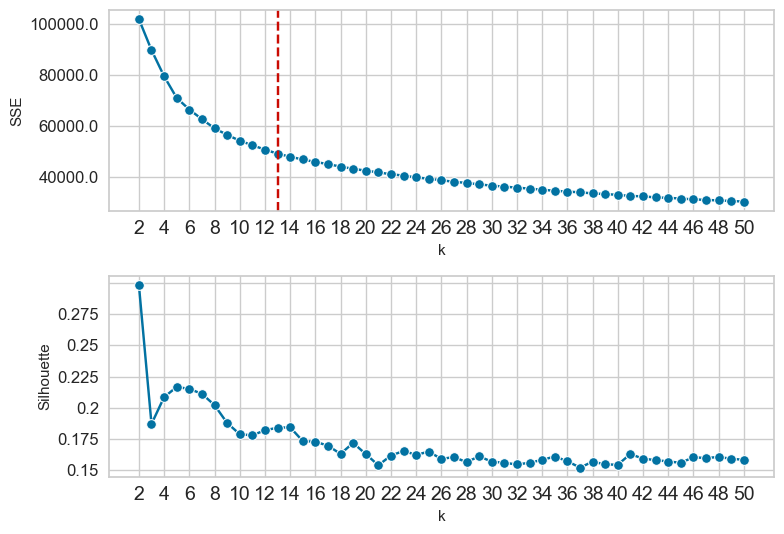

In [53]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))
axs[0].set_xticklabels(np.arange(2,51,2), fontsize=14)
axs[0].set_yticklabels(axs[0].get_yticks(), fontsize=12)

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set_yticklabels(axs[1].get_yticks(), fontsize=12)
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))
axs[1].set_xticklabels(np.arange(2,51,2), fontsize=14)

plt.tight_layout()

## k = 7
We choose 7 as a trade off between SSE and Silhouette Score.

In [19]:
k = 7

In [20]:
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
kmeans.fit(X)

KMeans(max_iter=100, n_clusters=7, n_init=10, random_state=0)

In [21]:
labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', kmeans.inertia_)
print('Silhouette score:', silhouette_score(X, kmeans.labels_))

Cluster sizes:
Cluster 0:	4841
Cluster 1:	1985
Cluster 2:	3424
Cluster 3:	1424
Cluster 4:	1985
Cluster 5:	1822
Cluster 6:	950

SSE: 62588.08236889872
Silhouette score: 0.18895016831033543


In [13]:
def compute_correlation(X, labels, dist = None):
    if dist is None:
        dist = squareform(pdist(X))

    # Compute the ideal similarity matrix
    shape = len(X)
    ideal_sim = np.eye(shape)

    for i in range(shape):
        for j in range(0, i + 1):
            ideal_sim[j][i] = 1 if labels[i] == labels[j] else 0

    # Make the matrix symmetric
    ideal_sim = ideal_sim + ideal_sim.T - np.diag(np.diag(ideal_sim))

    # Compute the correlation
    correlation, _ = pearsonr(dist[np.triu_indices(shape, k=1)],
                                ideal_sim[np.triu_indices(shape, k=1)])
    
    return correlation

In [14]:
corr = compute_correlation(X, kmeans.labels_, dist)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.45761581604649465


In [15]:
assert kmeans.cluster_centers_.shape[1] == len(numeric_df.columns), "Mismatch in features vs centroids"

C:\Users\camim\AppData\Local\Temp\ipykernel_15068\3005901508.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(centers))


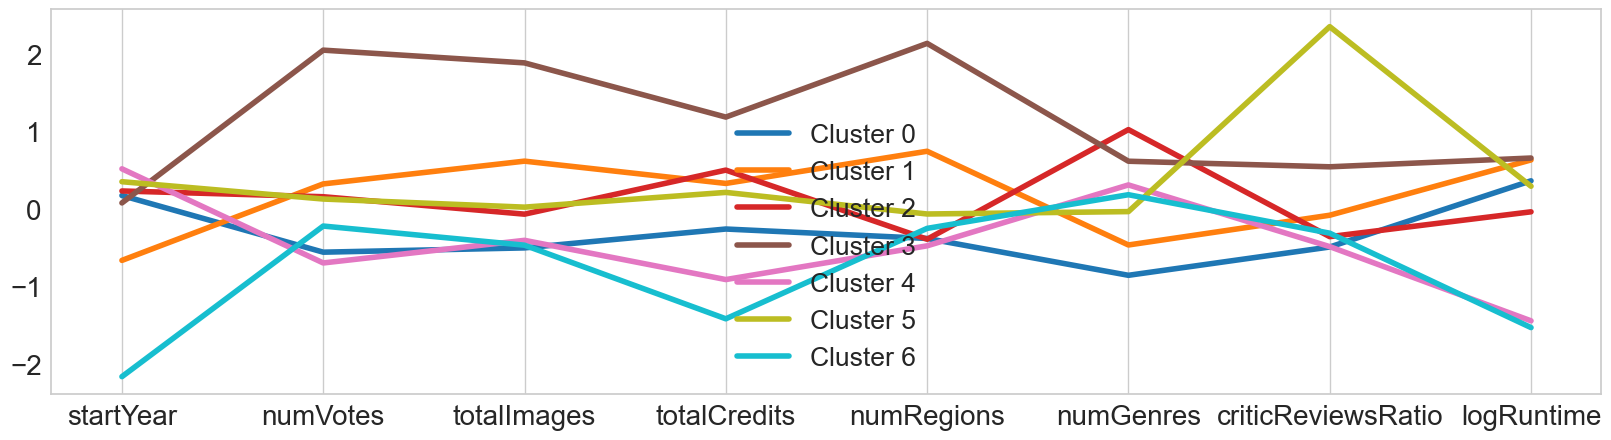

In [28]:
plt.figure(figsize=(20, 5))
centers = kmeans.cluster_centers_
colors = cm.get_cmap('tab10', len(centers)) 

for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label=f'Cluster {i}', linewidth=4, color=colors(i))
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=19, loc='best')
plt.grid(axis='y')

plt.show()

Cluster 3 is quite separated w/ particularly high values for `numVotes`, `totalImages`, `totalCredits`, and `numRegions`. Cluster 5 is characterized by having a particularly high `criticReviesRatio`. Cluster 4 and 6 have the lowest runtimes by far; Cluster 6 moreover seems to contain the oldest titles, and the ones with the the lowest number of credits. Clusters 0 and 2 are the least well separated from the others; they are indeed the biggest.


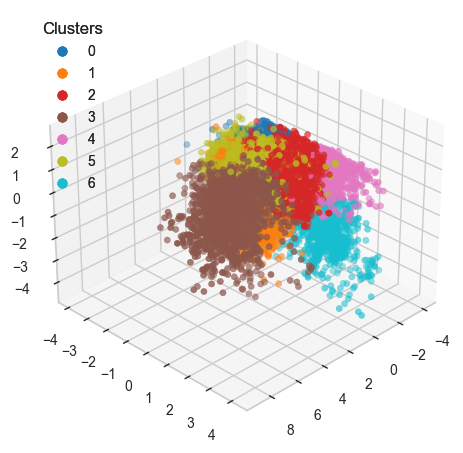

In [17]:
pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2', 'PC3'])
pca_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    pca_data['PC1'], 
    pca_data['PC2'], 
    pca_data['PC3'], 
    c=pca_data['cluster'].cat.codes, 
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=45)

plt.show()

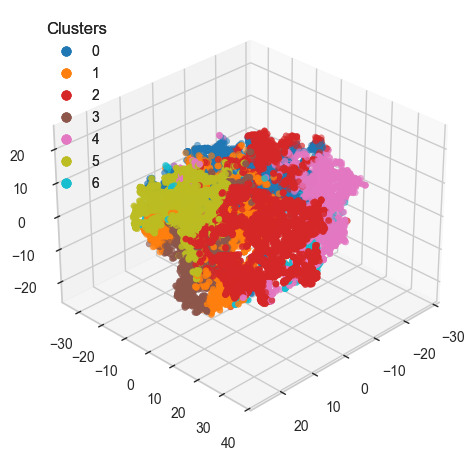

In [19]:
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_data = pd.DataFrame(tsne.fit_transform(X), columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    tsne_data['TSNE1'], 
    tsne_data['TSNE2'], 
    tsne_data['TSNE3'], 
    c=tsne_data['cluster'].cat.codes,  
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30, azim=45)

plt.show()

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\2208247306.py:6: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=kmeans.labels_, #numGenres and criticReviewsRatio: features that separate centroids the most


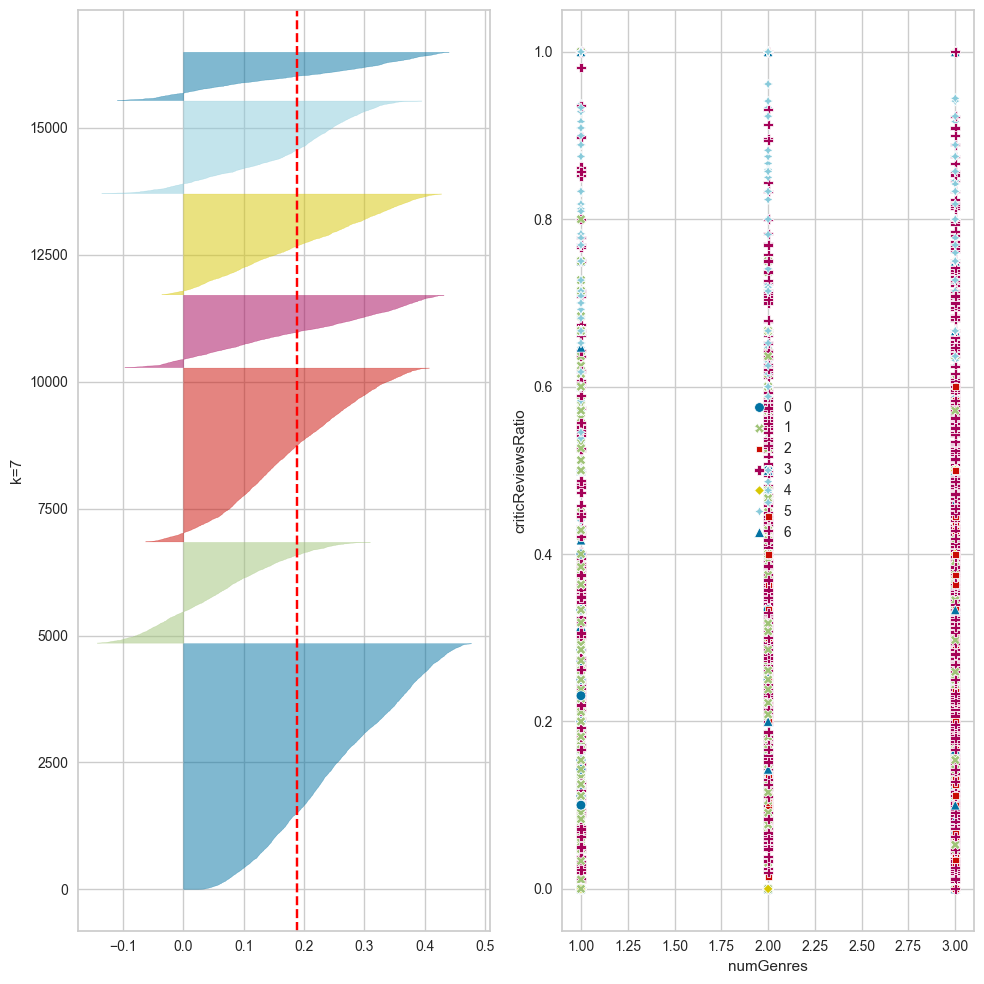

In [ ]:
"""
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size of axs array
visualizer = SilhouetteVisualizer(kmeans, colors=colors, ax=axs[0])
axs[0].set_ylabel("k=" + str(k))
visualizer.fit(X)
sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=kmeans.labels_, #numGenres and criticReviewsRatio: features that separate centroids the most
                palette=sns.color_palette(colors), style=kmeans.labels_, ax=axs[1])
plt.tight_layout()
plt.show()
"""

### Qualitative Evaluation
We visualize the distribution of the clusters against interesting known categorical features. We have some insights:
- `titleType`: the smallest cluster, 6, is the purest, being mainly made up of shorts. Though it's the bigger Cluster 4 that contains the largest amount of shorts, as well as some tvEpisodes. It is, followed by Cluster 6, the 'purest' cluster wrt to the most popular class, movie, that is well represented in all other clusters. Cluster 2 has a very large proportion of tvEpisode: the variable runtime of this type of title might explain why its centroid assumes the 'middle' value for this variable. The importance of 'logRuntime' for this clustering is also higlighted by the fact that the few tvShorts have been almost entirely distributed amongst these three clusters. Cluster 0, the biggest, contains a great number of almost all title types.
- `ratingNum`: they're normally distributed
- Boolean variables: all False for cluster 6, just a few Trues for `awardsAndNominations`. Cluster 3 shows a significant proportion of True for `hasVideo` and `awardsAndNomination` wrt the other clusters. This is also true for `moreCountriesOfOrigin`, but it's more subtle. If we look at its titleType composition, we see that it mostly contains movies and tvEpisodes. Since this cluster separated itself for high values of `numVotes`, `totalCredits`, `totalImages` and `numRegions`, but less so for `criticReviewsRatio`, we assume it contains mainstream popular content. Cluster 0 has the highest proportion for `canHaveEpisode`, since it contains the biggest amount of series.


A clear characterization emerges for Cluster 6: it mostly contains shorts, and it has very little to no True values for every boolean variable.
Since it's greatly made up of shorts, we can expect the very absence of Trues for `canHaveEpisodes`. Its records are produced in just one country, they have mostly no awards nor nominations (we could expect movies and tv series to gain more accolades) and no video content on their page (again, this could reasonably be a feature for blockbusters and mainstream tv series).

In [29]:
df_clusters = df.copy()
df_clusters['Labels'] = kmeans.labels_ #add cluster labels

In [30]:
categorical_feats = ["titleType","ratingNum", "canHaveEpisodes", "hasVideos", "moreCountriesOfOrigin", "awardsAndNominations"]

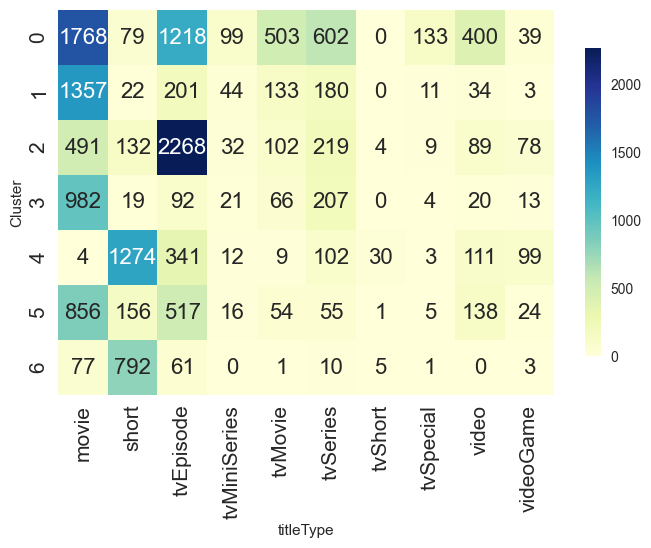

In [38]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df_clusters['Labels'], df_clusters['titleType'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', annot_kws={"size": 16}, cbar_kws={"shrink": 0.8})
#plt.title('Heatmap of Clusters vs titleType')
plt.xlabel('titleType')
plt.ylabel('Cluster')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

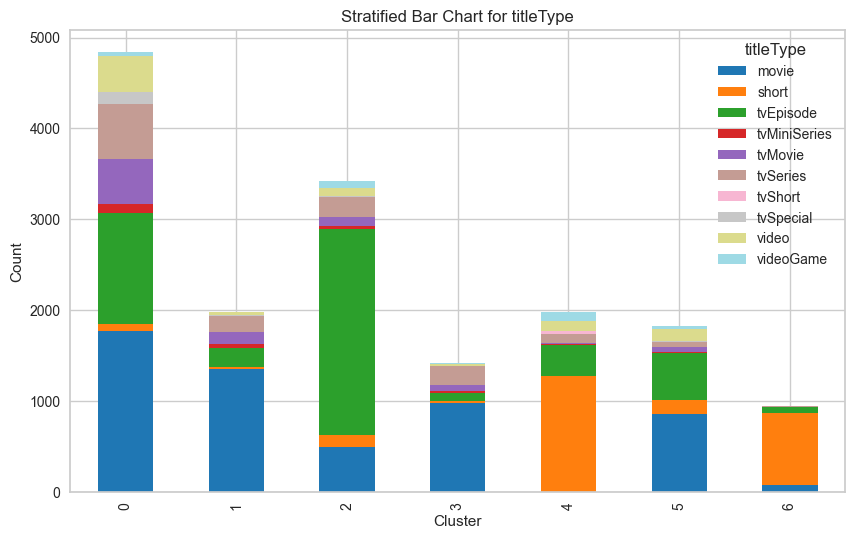

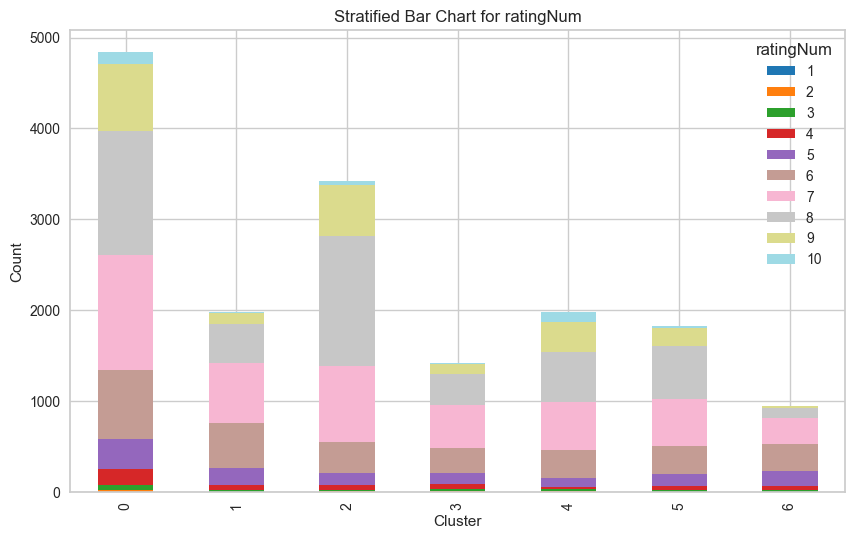

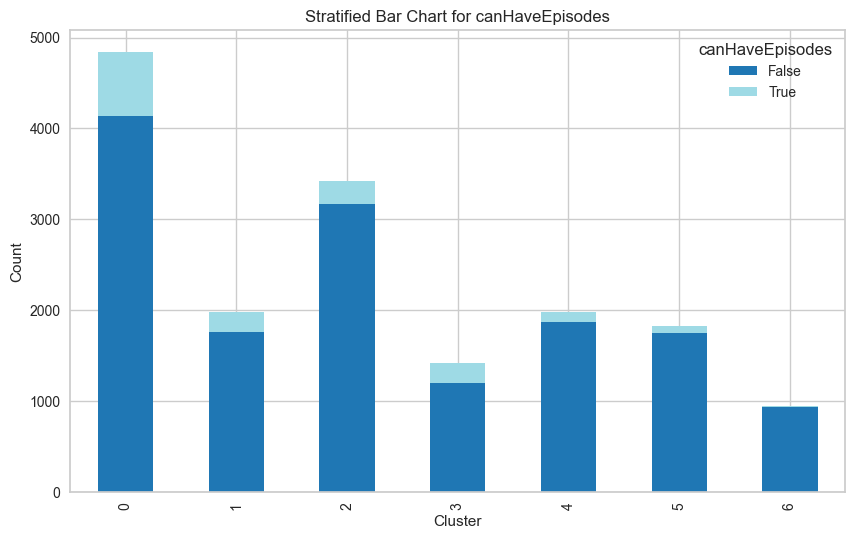

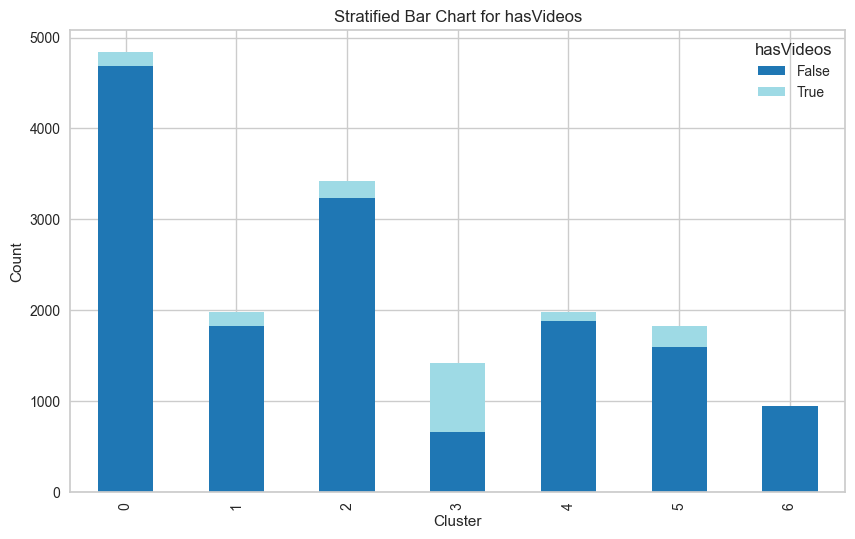

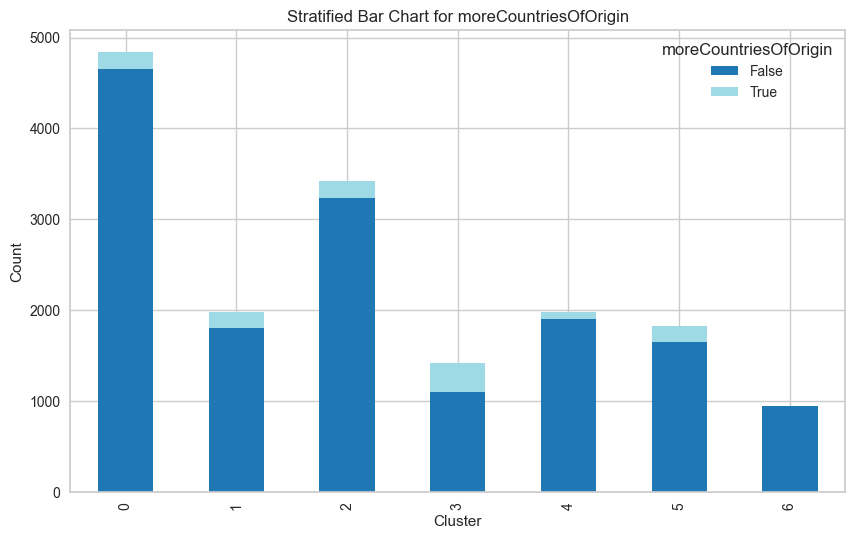

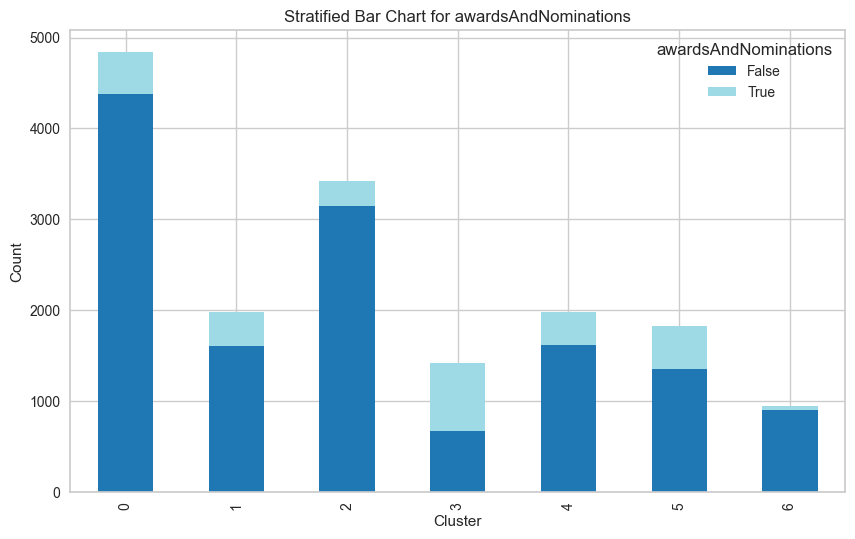

In [82]:
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters['Labels'], df_clusters[cat])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel("Cluster")
    plt.ylabel('Count')
    plt.legend(title=cat)
    plt.show()

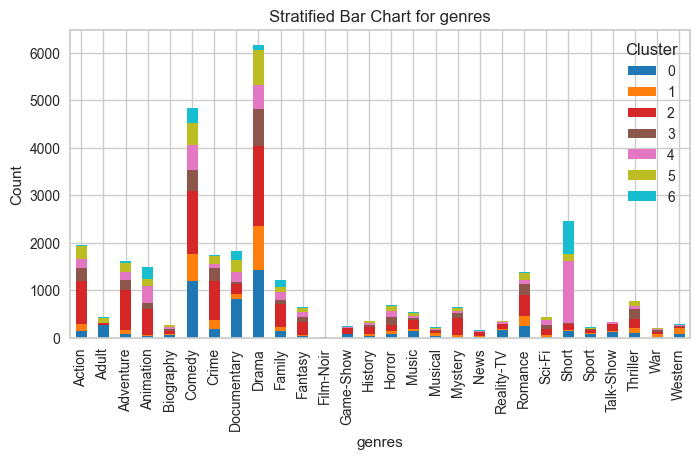

In [84]:
#not very informative: just the repetition of the info about shorts
df_clusters_expl = df_clusters.explode('genres')

ct = pd.crosstab(df_clusters_expl["genres"], df_clusters_expl['Labels'])
ct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='tab10')
plt.title(f'Stratified Bar Chart for genres')
plt.xlabel('genres')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

Let's explore how the clusters relate to the numeric variables we fed to the algorithm. We first get and idea from a pairplot, and then zoom into those that seem interesting.

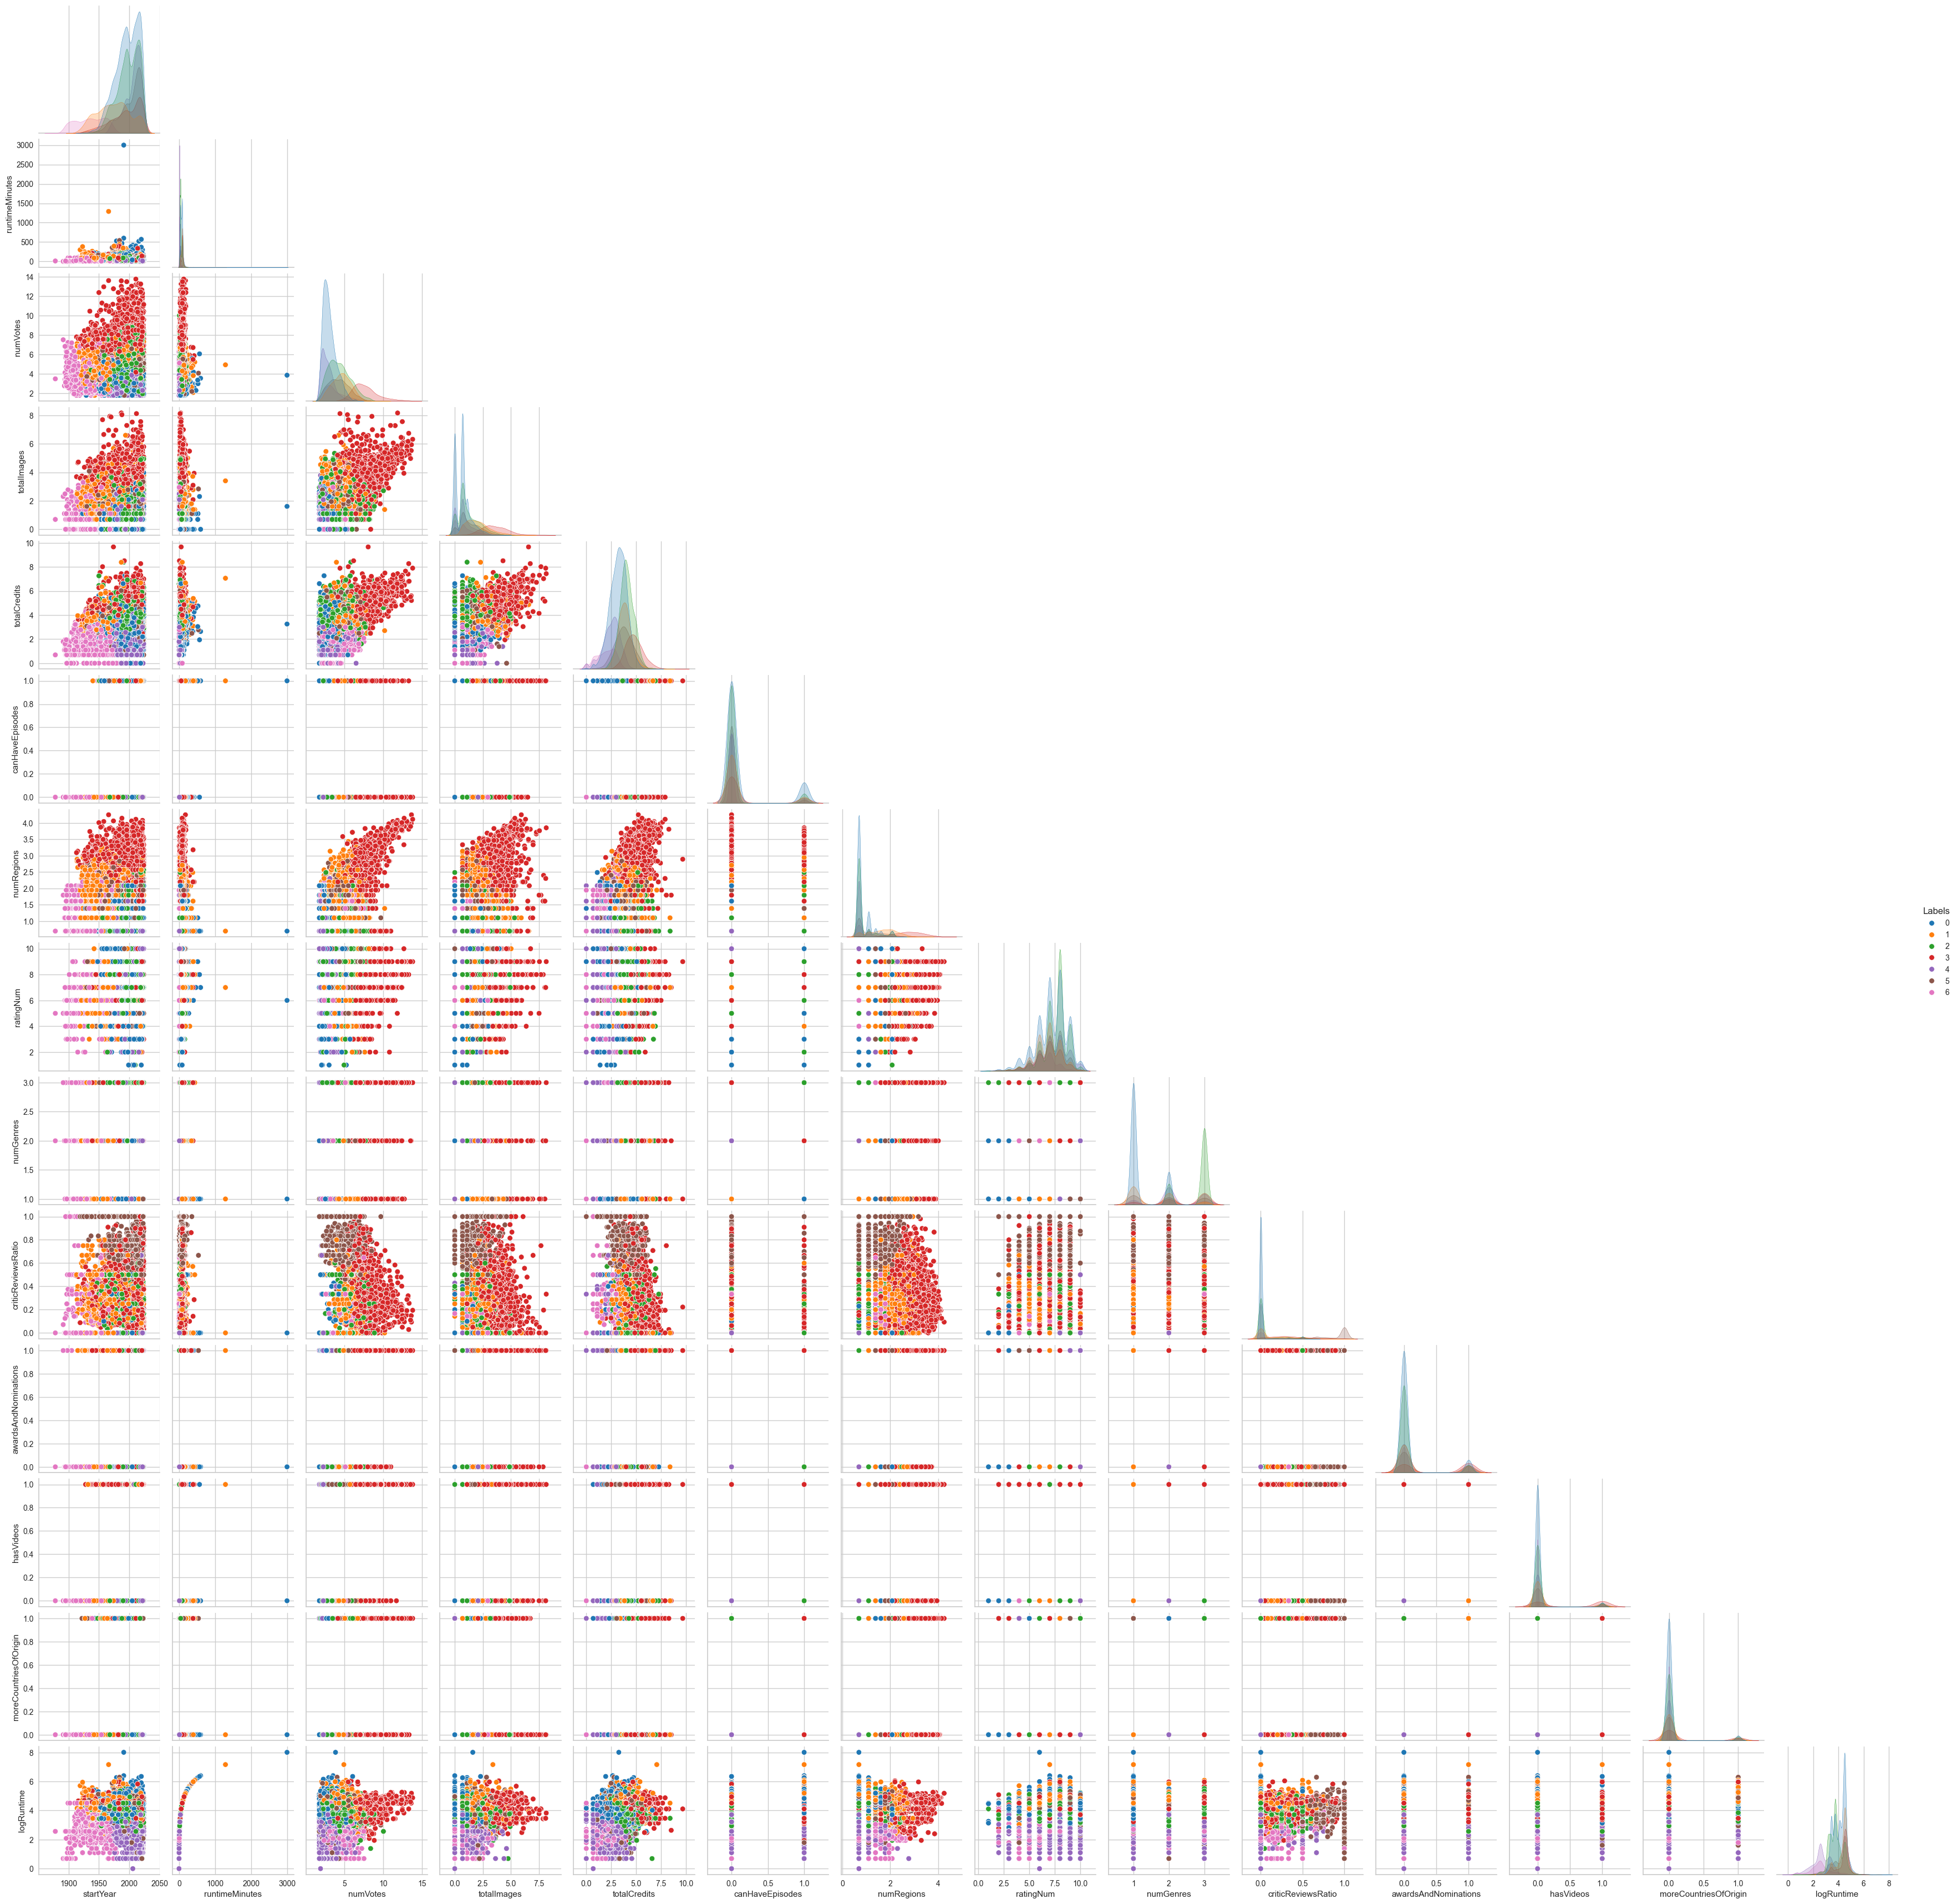

In [85]:
sns.pairplot(df_clusters, hue='Labels', diag_kind='kde', height=2.5, palette='tab10', corner=True)

Let's look at the clusters' composition wrt the numeric variables used by the algorithms.

- `numGenres`: interestingly, the purest clusters are the biggest
    - 0: mostly 1 genre, a minority of 2 genres
    - 2: mostly 3 genres, a minority of 2 genres.


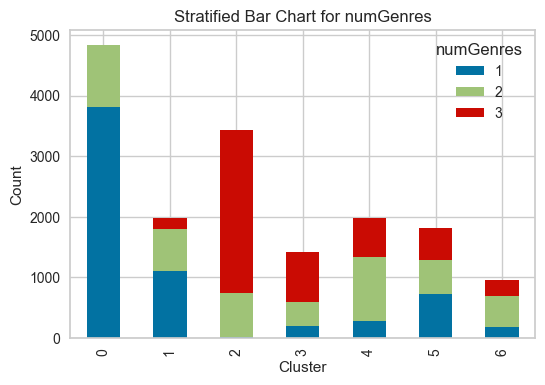

In [86]:
ct = pd.crosstab(df_clusters['Labels'], df_clusters['numGenres'])
ct.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title(f'Stratified Bar Chart for numGenres')
plt.xlabel("Cluster")
plt.ylabel('Count')
plt.legend(title="numGenres")
plt.show()

The distribution of the clusters wrt to `criticReviewsRatio` confirms what was hinted by the parallel coordinates plot.
- Cluster 5 is concentrated at 1.0: the reviews are mostly by critics.
- Cluster 1 and 3 have a broader distribution, though with much lower values. They are mostly made up of movies and tvEpisodes: probably have more reviews bc they're popular title types, but aren't worth much attention by the critics.
- All other clusters: skewed towards 0 (though with many outliers); probably few reviews overall.

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\550550712.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Boxplot of criticReviewsRatio')

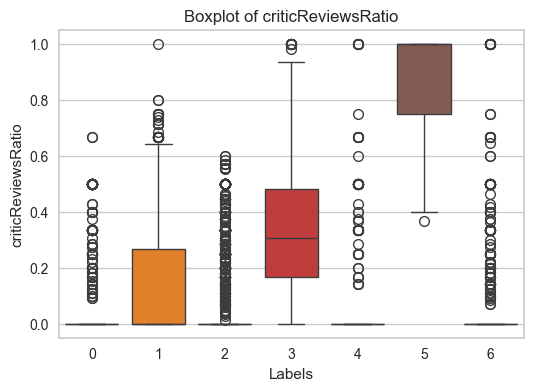

In [87]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_clusters, 
    x="Labels", 
    y="criticReviewsRatio", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)
plt.title("Boxplot of criticReviewsRatio")


- `startYear`: This information was clearly important.
    - 0: since 1936 (few from the 1920s)
    - 1: since 1913; mostly records from the 1930s til the 1990s
    - 2: since the 1940s
    - 3: since the 1920s
    - 4: since 1963 (no records before that)
    - 5: since the 1930s, but mostly since the 1960s
    - 6: UNTIL 1983 → contains the majority of older records (from before the 1930s)
- `runtimeMinutes`: coherent with the insights from titleType
    - Clusters 4 and 6: median around 12
    - Cluster 2 (mostly tvEpisode): median at 40
    - Cluster 0 (biggest): around 62 → probably the avg value among longer movies, shorter videos and tvEpisodes: box goes from around 40 to 90
    - All others: between 76 and 90 minutes → they contain many movies, the most popular title Type.

In [46]:
# Define start_year_counts_by_cluster
start_year_counts_by_cluster = df_clusters.groupby(['Labels', 'startYear']).size().unstack(fill_value=0)

fig = go.Figure()

# Add a line for each cluster
for cluster in start_year_counts_by_cluster.index:
    fig.add_trace(go.Scatter(
        x=start_year_counts_by_cluster.columns,
        y=start_year_counts_by_cluster.loc[cluster],
        mode='lines+markers',
        name=f'Cluster {cluster}'
    ))

# Update layout for better interactivity
fig.update_layout(
    #title='Number of Titles by Year for Each Cluster',
    xaxis_title='Year',
    yaxis_title='Number of Titles',
    #legend_title='Clusters',
    hovermode='x unified',
    margin=dict(l=30, r=30, t=20, b=30),
    height=400,
    width=800,
    legend=dict(
        x=0.01,         # Horizontal position (0 = left, 1 = right)
        y=0.99,         # Vertical position (0 = bottom, 1 = top)
        bgcolor='rgba(255,255,255,0.5)',  # Semi-transparent background
        bordercolor='gray',
        borderwidth=1
    ),
    font=dict(size=20)

)

fig.show()


C:\Users\camim\AppData\Local\Temp\ipykernel_6232\360439415.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




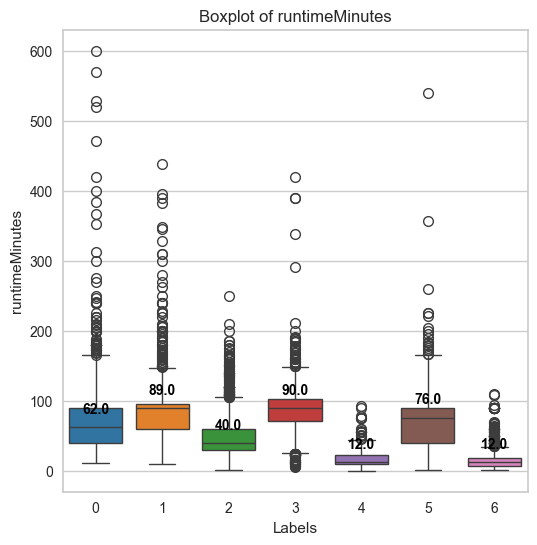

In [89]:
df_clusters_filt = df_clusters[df_clusters['runtimeMinutes'] <= 1000]  # filter outliers for better visualization

plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=df_clusters_filt, 
    x="Labels", 
    y="runtimeMinutes", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)

# Calculate and annotate the median for each cluster
medians = df_clusters_filt.groupby("Labels")["runtimeMinutes"].median()
for i, median in enumerate(medians):
    ax.annotate(
        f'{median:.1f}', 
        xy=(i, median), 
        xytext=(0, 10), 
        textcoords='offset points', 
        ha='center', 
        color='black', 
        fontsize=10, 
        fontweight='bold'
    )

plt.title("Boxplot of runtimeMinutes")
plt.show()

Let's look at `numVotes`, `numRegions`, `totalCredits` and `totalImages`. Mostly confirmation of what emerged from the parallel coordinates plot.
- For all: highest values for cluster 3
- `numVotes`: lowest values for 4, 0 and 6. All have some variability (wide boxes)
- `numRegions`: at second place cluster 1, w/ much variability. All others skewed towards lower values, especially 2 and 4.
- `totalCredits`: all have decently wide boxes; lowest median values for 4 and 6 (the 'shorts' clusters)
- `totalImages`: lowest values for 0, 4 and 6.



C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




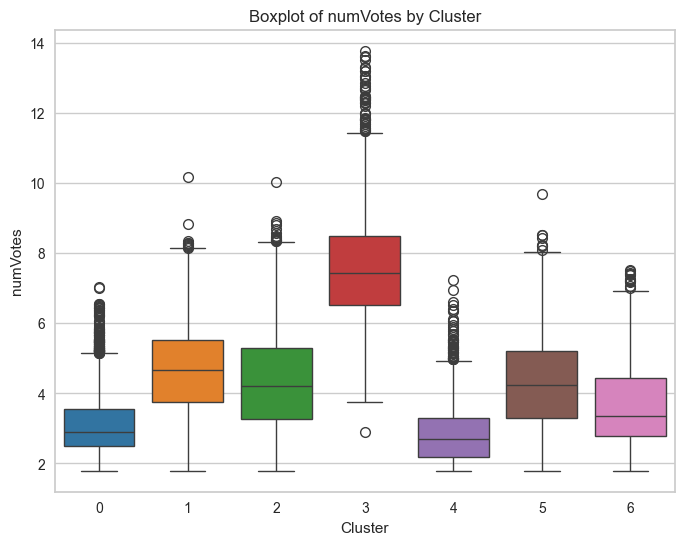

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




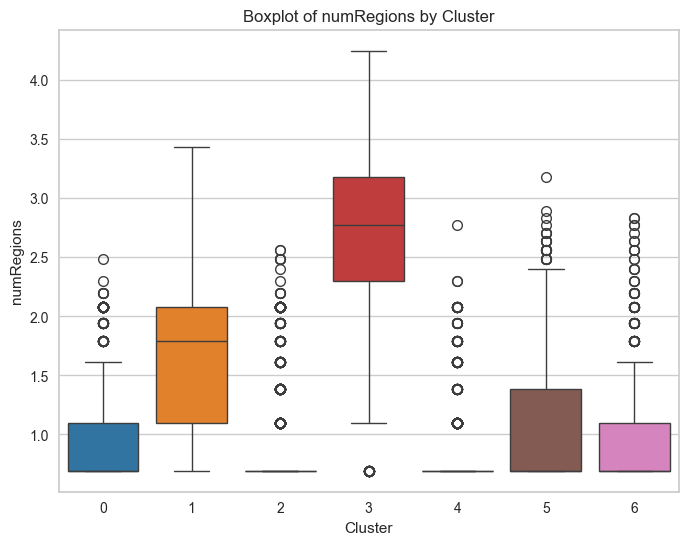

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




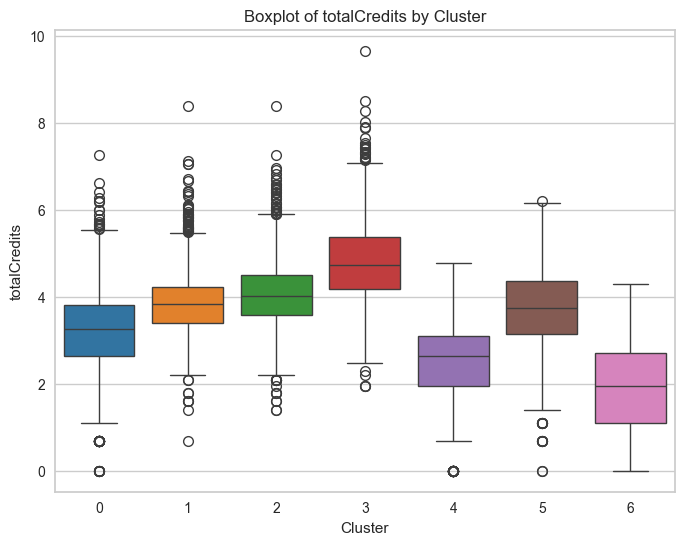

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




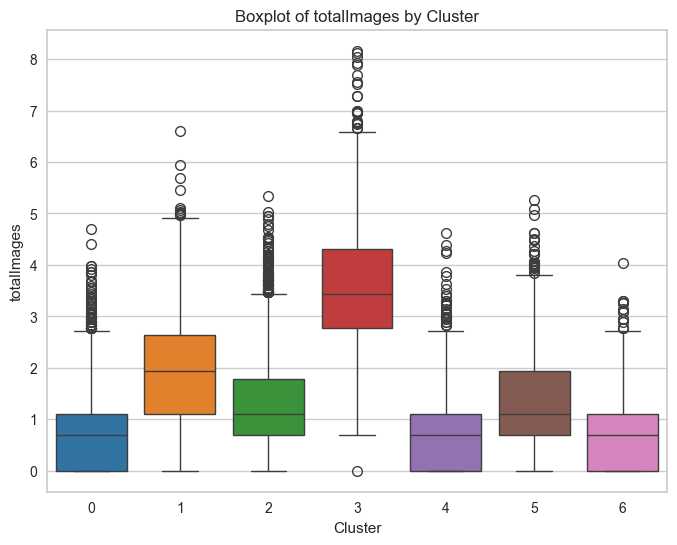

In [ ]:
for col in ["numVotes", "numRegions", "totalCredits", "totalImages"]:
    plt.figure(figsize=(8, 6))xx
    sns.boxplot(
        data=df_clusters, 
        x="Labels", 
        y=col, 
        palette="tab10",
        order=sorted(df_clusters['Labels'].unique())
    )
    plt.title(f"Boxplot of {col} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()

### Statistical frameworks for cluster validity: SSE
(too computationally expensive to validate correlation)

Our clustering's SSE is significantly lower than the SSE found in the clustering of 500 randomly generated datasets, which suggests that the clusters found by K-Means in our dataset are meaningful and not a product of chance.

In [22]:
my_sse = kmeans.inertia_
my_sse

62588.08236889872

In [23]:
N = 500
sse_stats = []

for _ in range(N):
    Xi = np.zeros(shape=X.shape)

    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min_, max_, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min_, max_, (1, nor))

    kmeans_rand = KMeans(n_clusters=7, n_init=10, max_iter=100, random_state=94)
    kmeans_rand.fit(Xi)
    sse_stats.append(kmeans_rand.inertia_)


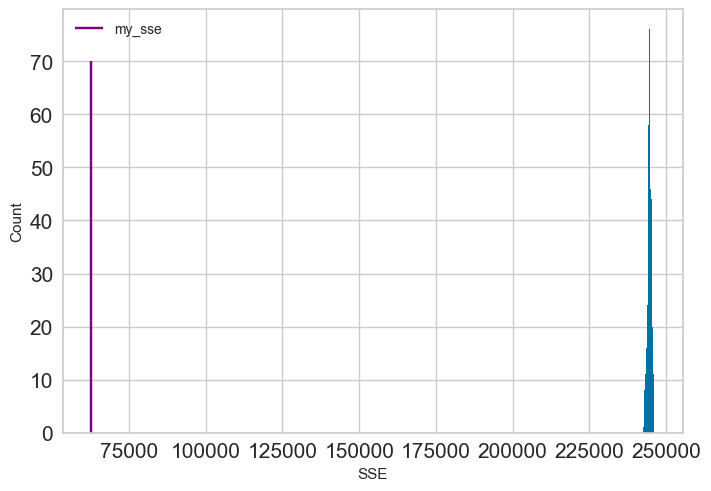

In [24]:
plt.hist(sse_stats, bins='auto')
plt.vlines(x = my_sse, ymin = 0, ymax = 70, colors = 'purple', label = 'my_sse')
plt.xlabel('SSE')
plt.ylabel('Count')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()

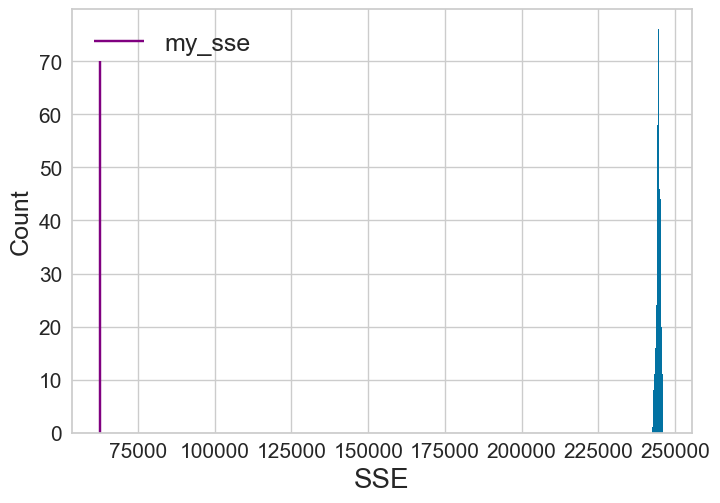

In [30]:
# REPORT
plt.hist(sse_stats, bins='auto')
plt.vlines(x = my_sse, ymin = 0, ymax = 70, colors = 'purple', label = 'my_sse')
plt.xlabel('SSE', fontsize =20)
plt.ylabel('Count', fontsize =18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize= 18, loc = 'best')
plt.show()

In [ ]:
"""
my_corr = corr
N = 100
corr_stats = []

for _ in range(N):
    Xi = np.zeros(shape=X.shape)
    
    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min, max, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min, max, (1, nor))
    
    kmeans = KMeans(n_clusters=8, n_init=10, max_iter=100, random_state=94)
    kmeans.fit(Xi)

    corr = compute_correlation(Xi, kmeans.labels_)
    corr_stats.append(corr)
"""

In [ ]:
"""
plt.hist(corr_stats, bins='auto')
plt.vlines(x = my_corr, ymin = 0, ymax = 60, colors = 'purple', label = 'my_corr')
plt.xlabel('Correlation')
plt.ylabel('Count')
plt.legend()
plt.show()
"""

# Bisecting K-means

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df.values)

In [6]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X))

for k in range(2, 51): 
    bkmeans = BisectingKMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    bkmeans.fit(X)
    sse_list.append(bkmeans.inertia_)
    sil_list.append(silhouette_score(dist, bkmeans.labels_, metric='precomputed'))

CPU times: total: 3min 44s
Wall time: 1min 55s


In [7]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 14


In [8]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 2, score = 0.25937849228563964
k = 4, score = 0.1619034693519066
k = 3, score = 0.1605270471778315
k = 7, score = 0.15889048686619173
k = 5, score = 0.15431251760045078
k = 6, score = 0.15019404867935915
k = 8, score = 0.12511701039442938
k = 14, score = 0.12272722399633507
k = 13, score = 0.11802480920941971
k = 12, score = 0.11725683549357531
k = 15, score = 0.11342177370007096
k = 9, score = 0.11182812461872442
k = 17, score = 0.10963624772407654
k = 16, score = 0.108471239324441
k = 11, score = 0.10769635247021539


C:\Users\camim\AppData\Local\Temp\ipykernel_38964\2251960231.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels(axs[0].get_yticks(), fontsize=12)


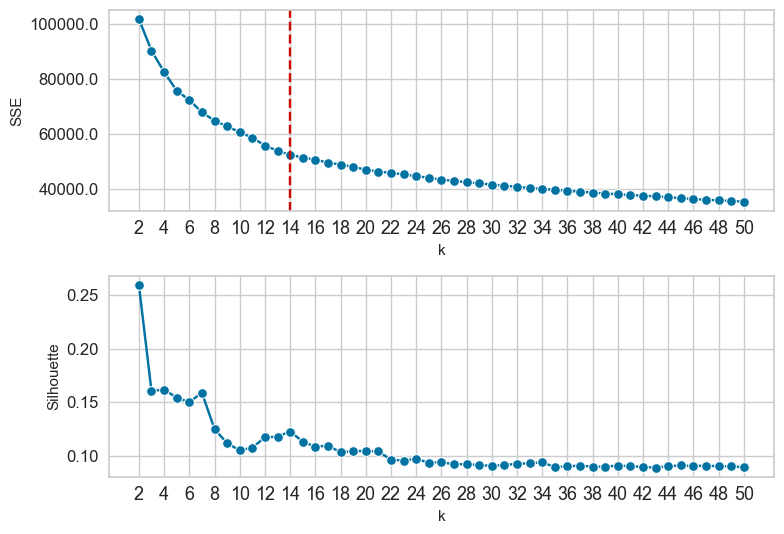

In [10]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))
axs[0].set_xticklabels(np.arange(2,51,2), fontsize=13)
axs[0].set_yticklabels(axs[0].get_yticks(), fontsize=12)

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))
axs[1].set_xticklabels(np.arange(2,51,2), fontsize=13)
axs[1].tick_params(axis='y', which='major', labelsize=12)
plt.tight_layout()

C:\Users\camim\AppData\Local\Temp\ipykernel_38964\1506364269.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([f"{int(y/1000)}k" if y >= 1000 else str(int(y)) for y in axs[0].get_yticks()], fontsize=14)


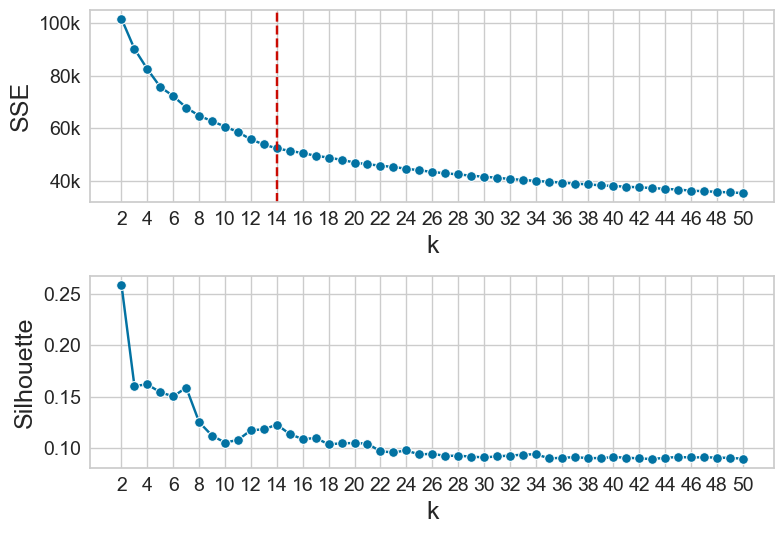

In [17]:
# REPORT

fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set_xlabel('k', fontsize=18)
axs[0].set_ylabel('SSE', fontsize=18)
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))
axs[0].set_xticklabels(np.arange(2,51,2), fontsize=14)
# Format y-tick labels in thousands with 'k'
axs[0].set_yticklabels([f"{int(y/1000)}k" if y >= 1000 else str(int(y)) for y in axs[0].get_yticks()], fontsize=14)

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set_xlabel('k', fontsize=18)
axs[1].set_ylabel('Silhouette', fontsize=18)
axs[1].set_xticks(np.arange(2,51,2))
axs[1].set_xticklabels(np.arange(2,51,2), fontsize=14)
axs[1].tick_params(axis='y', which='major', labelsize=14)
plt.tight_layout()

We select k = 7; the only significant local peak for silhouette.

In [62]:
k = 7

In [63]:
bkmeans = BisectingKMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
bkmeans.fit(X)

BisectingKMeans(max_iter=100, n_clusters=7, n_init=10, random_state=0)

In [64]:
labels, counts = np.unique(bkmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', bkmeans.inertia_)
print('Silhouette score:', silhouette_score(X, bkmeans.labels_))

Cluster sizes:
Cluster 0:	1881
Cluster 1:	1398
Cluster 2:	1397
Cluster 3:	1712
Cluster 4:	3595
Cluster 5:	4184
Cluster 6:	2264

SSE: 67857.02253696292
Silhouette score: 0.12785666313535105


In [99]:
corr = compute_correlation(X, bkmeans.labels_, dist)
print(f"Correlation between the distance matrix and the ideal similarity matrix: {corr}")

Correlation between the distance matrix and the ideal similarity matrix: -0.3929864505153289


C:\Users\camim\AppData\Local\Temp\ipykernel_15068\2394284964.py:3: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



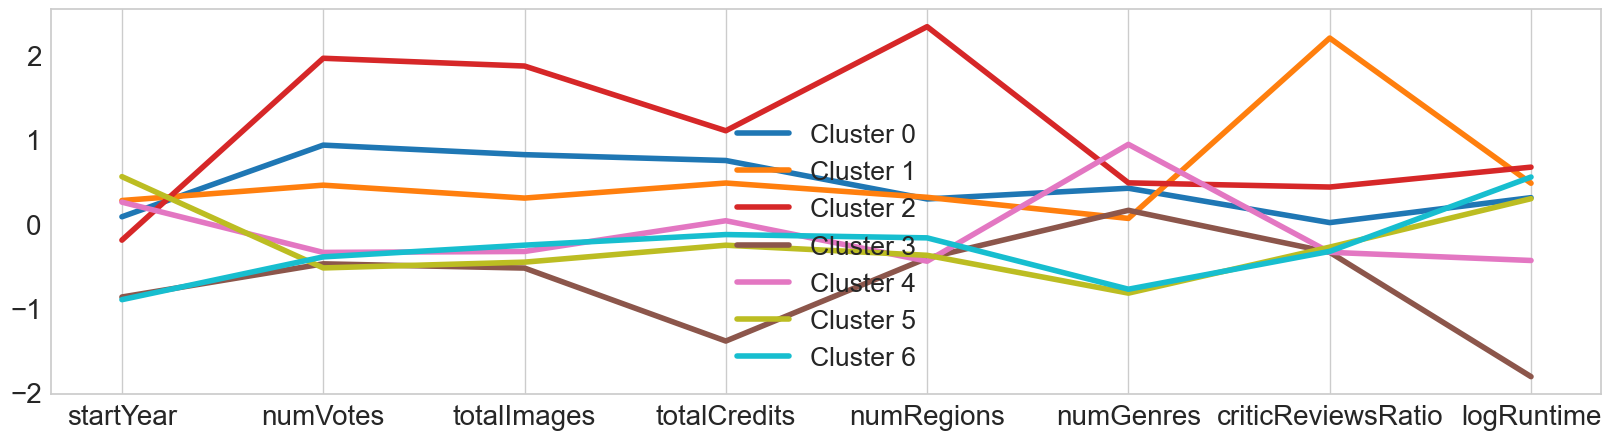

In [65]:
plt.figure(figsize=(20, 5))
centers = bkmeans.cluster_centers_
colors = cm.get_cmap('tab10', len(centers))
for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=4, color=colors(i))
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=19, loc='best')
plt.grid(axis='y')

plt.show()

The centroids are particularly well separated wrt `totalCredits`.
Cluster 2 is particularly well separated thanks to its high values for `numVotes`, `totalImages`, `totalCredits` and `numRegions`. It is followed by cluster 0 and 1.

Clusters 3 and 6 have the lowest values for `startYear`. Cluster 3 also has a particularly low value for `totalCredits` and `logRuntime`: it probably contains older shorts. Cluster 4 also has a lower value for `logRuntime` wrt to the remaining clusters.

Cluster 1 has a very high value for `criticReviesRatio`.

Clusters 5 (the biggest) and 0 are the least well separated.


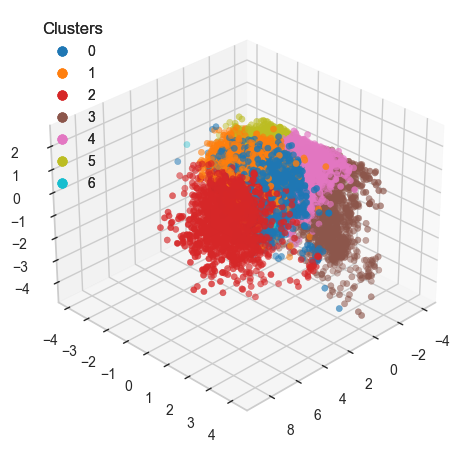

In [102]:
pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(bkmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'].cat.codes, cmap='tab10')
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=45)

plt.show()

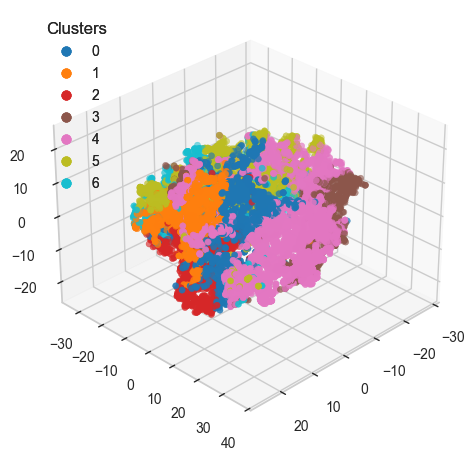

In [103]:
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_data = pd.DataFrame(tsne.fit_transform(X), columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_data['cluster'] = pd.Categorical(bkmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    tsne_data['TSNE1'], 
    tsne_data['TSNE2'], 
    tsne_data['TSNE3'], 
    c=tsne_data['cluster'].cat.codes,  
    cmap='tab10'
)
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30, azim=45)

plt.show()

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1960751410.py:6: UserWarning:


The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.



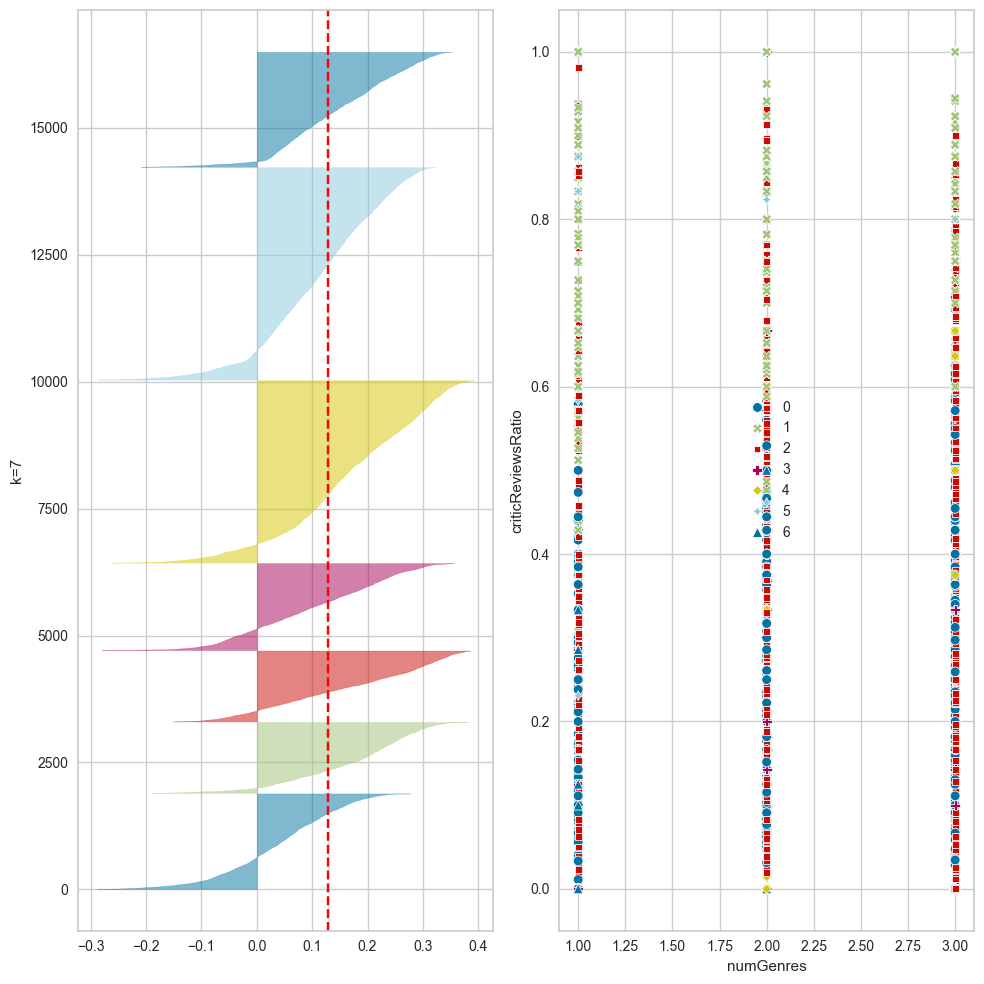

In [ ]:
"""
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
fig, axs = plt.subplots(1, 2, figsize=(10, 10))  # Adjust the size of axs array
visualizer = SilhouetteVisualizer(bkmeans, colors=colors, ax=axs[0])
axs[0].set_ylabel("k=" + str(k))
visualizer.fit(X)
sns.scatterplot(data=df, x="numGenres", y="criticReviewsRatio", hue=bkmeans.labels_, 
                palette=sns.color_palette(colors), style=bkmeans.labels_, ax=axs[1])
plt.tight_layout()
plt.show()
"""

### Qualitative Evaluation
We visualize the distribution of the clusters against interesting known categorical features. We have some insights:
- `titleType`: Again, the distribution of shorts is what becomes immediately evident. Around half of them are to be found in Cluster 3, which also has a small proportion of tvEpisodes and is the only cluster with ver little movies. Cluster 4, the 2nd most populous cluster, is mostly made of tvEpisodes and a smaller, yet significant, proportion of shorts. The few tvShort record are also distributed among these 2 clusters. It's also to be noted that cluster 6 contains the biggest number of movies, although being only the 3rd most popular, and that Cluster 2 is the only cluster with almost no tvEpisodes. Cluster 5, the biggest, contains the largest part of the remaning title types (except videogame → mostly 4)
- `ratingNum`: they're normally distributed
- Boolean variables: Cluster 3, the shorts cluster, has very little True values for all features (more for awardsAndNominations). Same thing for Cluster 6, which has virtually no True values for hasVideos. Cluster 5 has the biggest n. of True values for canHaveEpisode: it contains the most series. Cluster 2 has the biggest number for the remaining boolean variable; in particular, it has around 50% True values for hasVideos and awardsAndNominations: it probably contains mainstream titles.

In [66]:
df_clusters['Labels'] = bkmeans.labels_ #overwrite cluster labels

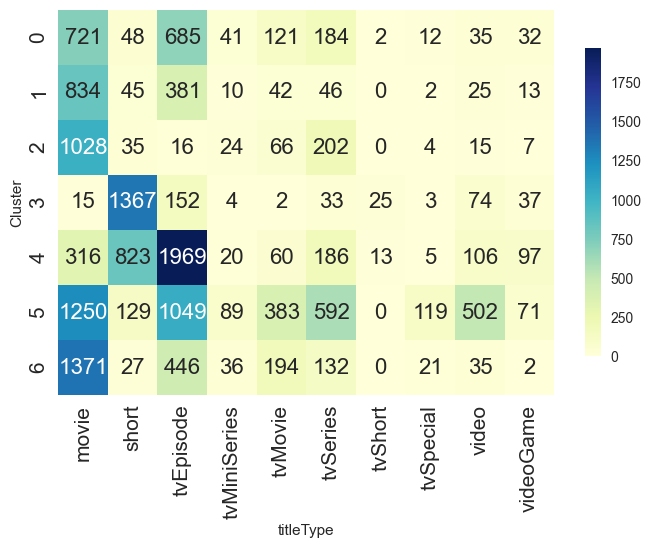

In [67]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df_clusters['Labels'], df_clusters['titleType'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', annot_kws={"size": 16}, cbar_kws={"shrink": 0.8})
#plt.title('Heatmap of Clusters vs titleType')
plt.xlabel('titleType')
plt.ylabel('Cluster')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

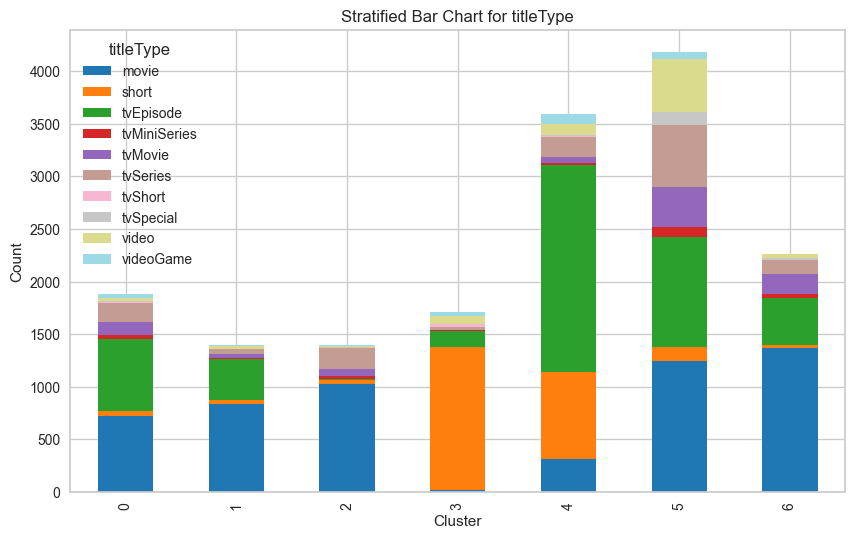

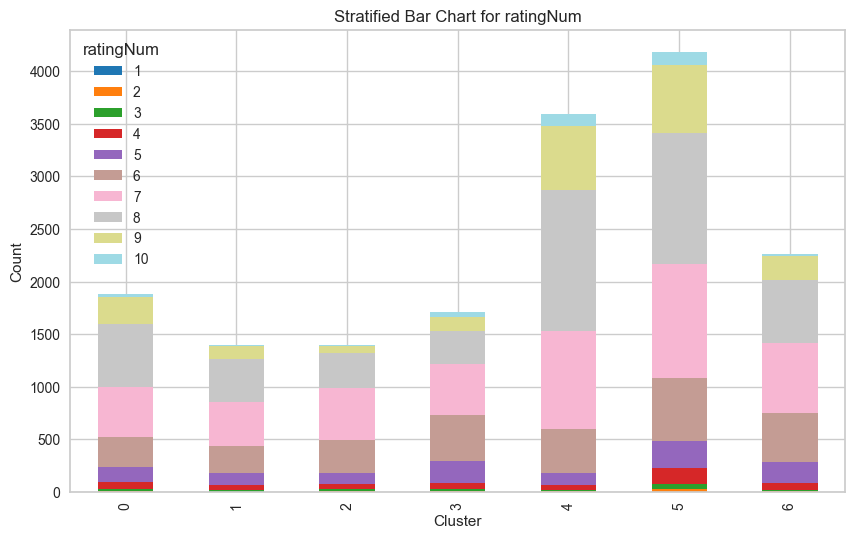

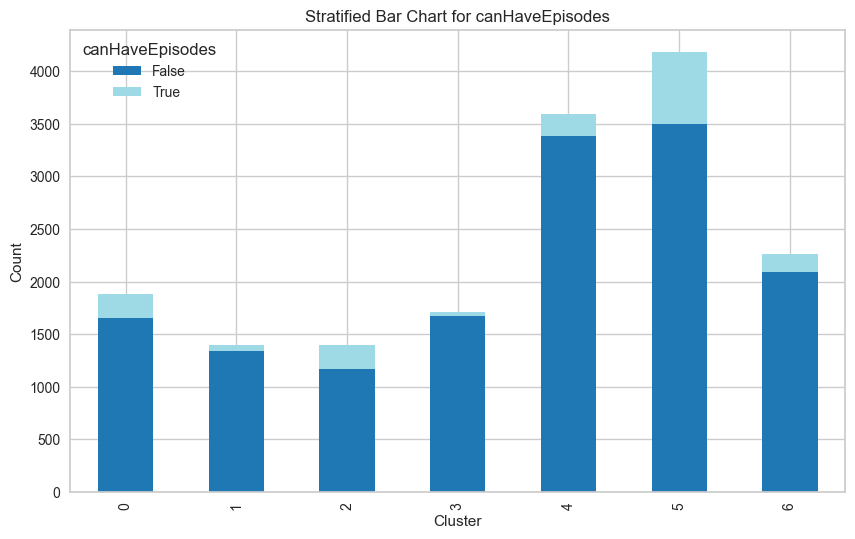

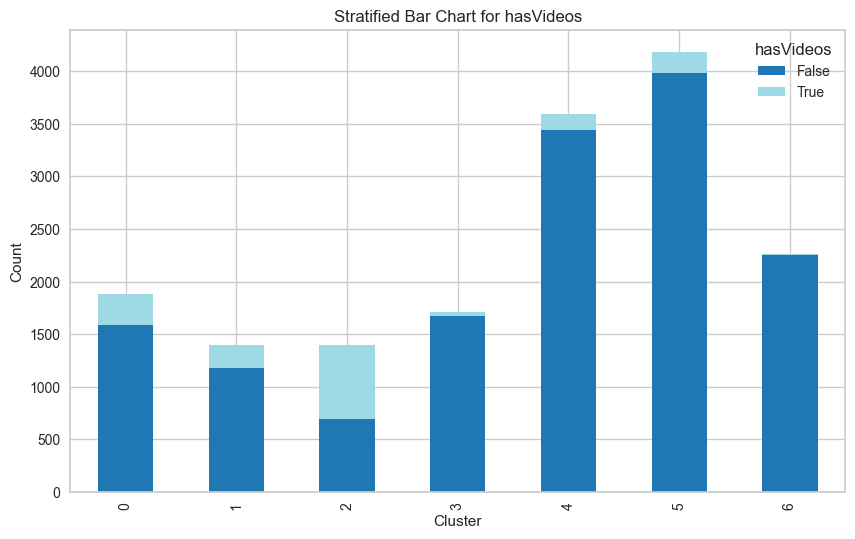

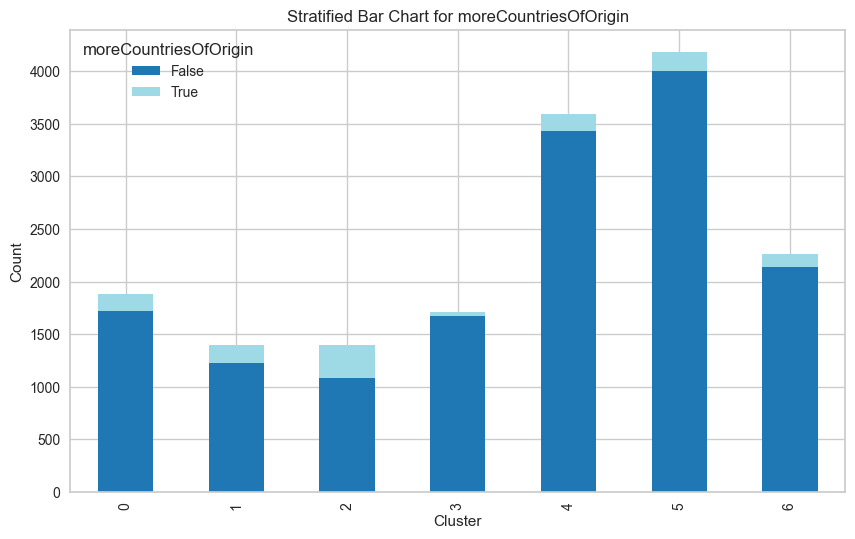

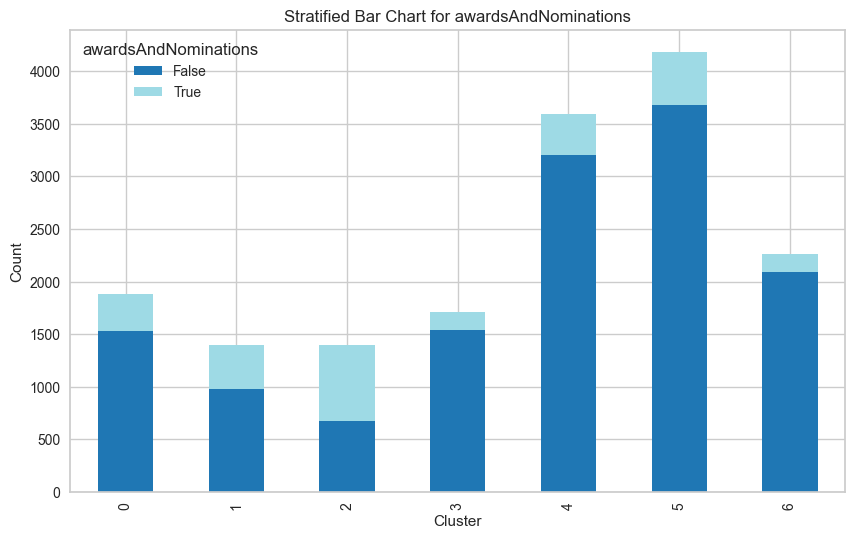

In [112]:
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters['Labels'], df_clusters[cat])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel("Cluster")
    plt.ylabel('Count')
    plt.legend(title=cat)
    plt.show()

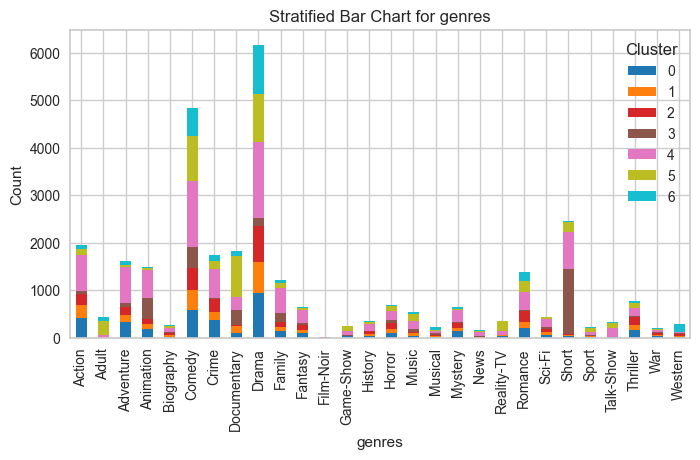

In [113]:
#not very informative: just the repetition of the info about shorts
df_clusters_expl = df_clusters.explode('genres')

ct = pd.crosstab(df_clusters_expl["genres"], df_clusters_expl['Labels'])
ct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='tab10')
plt.title(f'Stratified Bar Chart for genres')
plt.xlabel('genres')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

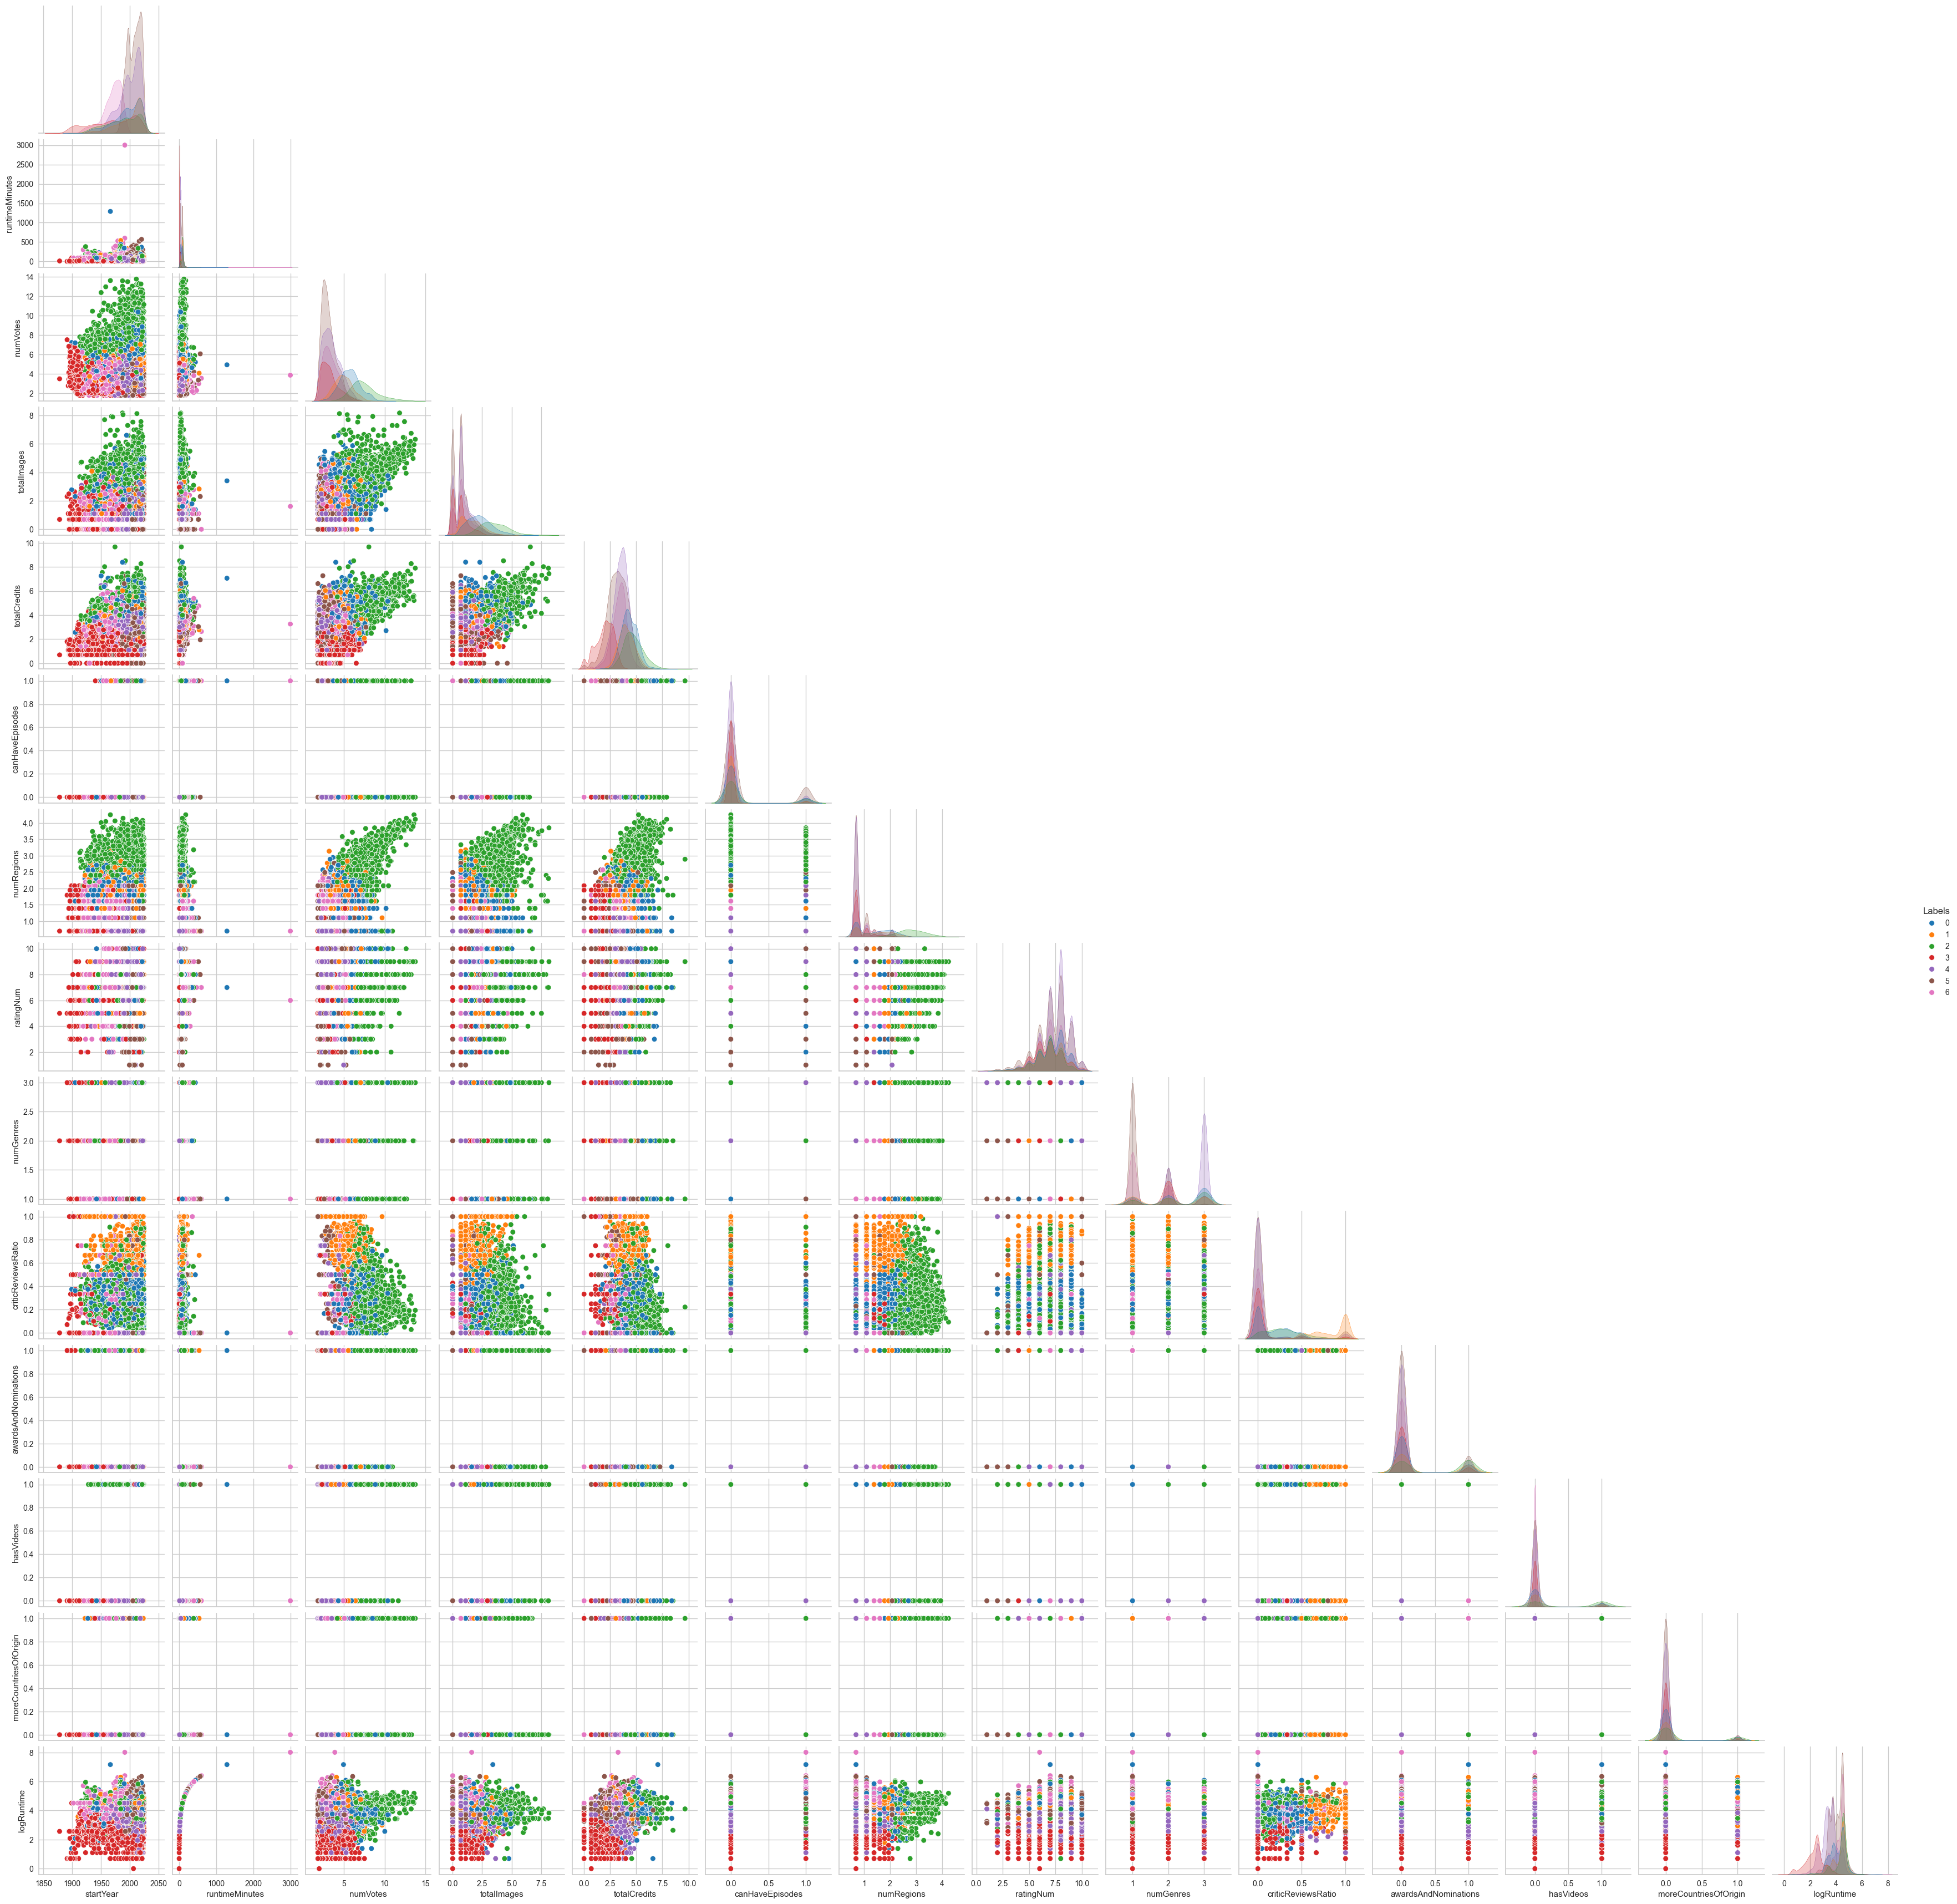

In [114]:
sns.pairplot(df_clusters, hue='Labels', diag_kind='kde', height=2.5, palette='tab10', corner=True)

Let's look at the clusters' composition wrt the numeric variables used by the algorithms.

- `numGenres`: less pure clusters
    - 5 and 6: mostly 1 genre, a minority of 2 genres, and very few 3 genres.
    - 4: purest, mostly 3 2/ a proportion of 2.


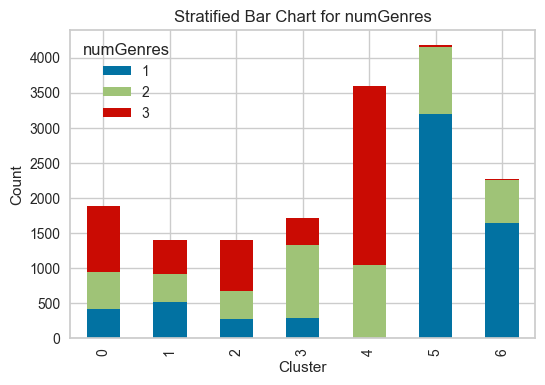

In [115]:
ct = pd.crosstab(df_clusters['Labels'], df_clusters['numGenres'])
ct.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title(f'Stratified Bar Chart for numGenres')
plt.xlabel("Cluster")
plt.ylabel('Count')
plt.legend(title="numGenres")
plt.show()

→ similar to KMeans

The distribution of the clusters wrt to `criticReviewsRatio` confirms what was hinted by the parallel coordinates plot.
- Cluster 1 is concentrated at 1.0: the reviews are mostly by critics.
- Cluster 0 and 2 have a broader distribution, though with much lower values. They are mostly made up of movies and tvEpisodes: probably have more reviews bc they're popular title types, but aren't worth much attention by the critics.
- All other clusters: skewed towards 0 (though with many outliers); probably few reviews overall.

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\550550712.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Boxplot of criticReviewsRatio')

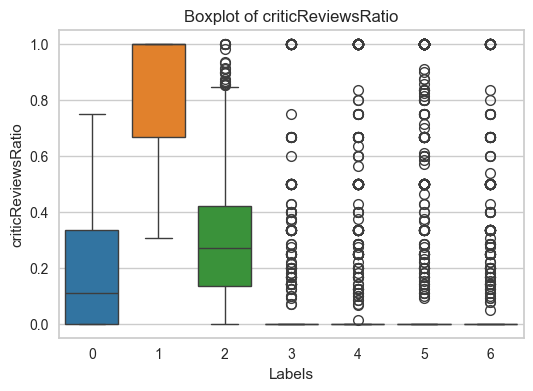

In [116]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_clusters, 
    x="Labels", 
    y="criticReviewsRatio", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)
plt.title("Boxplot of criticReviewsRatio")


- `startYear`: This information was clearly important. DIFFERENCES TO KMEANS
    - 3: the one containing the oldest titles, but it actually has titles from all years → not just the "oldest shorts"
    - 5: since 1980s (no titles before)
    - 4: since the 1930s, but mostly since the 1960s
    - 6: only has titles from the 1910s to 1999
- `runtimeMinutes`: coherent with the insights from titleType
    - Shorter: cluster 3 median 11 (mostly shorts), cluster 4 median 30 (mostly tvEpisodes + shorts)s

In [68]:
# Define start_year_counts_by_cluster
start_year_counts_by_cluster = df_clusters.groupby(['Labels', 'startYear']).size().unstack(fill_value=0)

fig = go.Figure()

# Add a line for each cluster
for cluster in start_year_counts_by_cluster.index:
    fig.add_trace(go.Scatter(
        x=start_year_counts_by_cluster.columns,
        y=start_year_counts_by_cluster.loc[cluster],
        mode='lines+markers',
        name=f'Cluster {cluster}'
    ))

# Update layout for better interactivity
fig.update_layout(
    #title='Number of Titles by Year for Each Cluster',
    xaxis_title='Year',
    yaxis_title='Number of Titles',
    #legend_title='Clusters',
    hovermode='x unified',
    margin=dict(l=30, r=30, t=20, b=30),
    height=400,
    width=800,
    legend=dict(
        x=0.01,         # Horizontal position (0 = left, 1 = right)
        y=0.99,         # Vertical position (0 = bottom, 1 = top)
        bgcolor='rgba(255,255,255,0.5)',  # Semi-transparent background
        bordercolor='gray',
        borderwidth=1
    ),
    font=dict(size=20)

)

fig.show()


C:\Users\camim\AppData\Local\Temp\ipykernel_6232\360439415.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




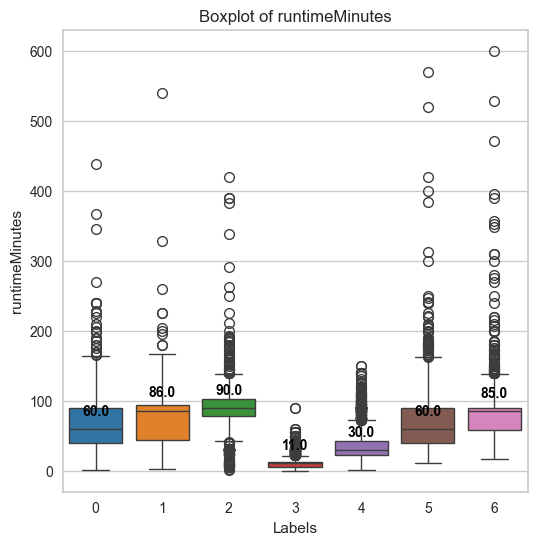

In [118]:
df_clusters_filt = df_clusters[df_clusters['runtimeMinutes'] <= 1000]  # filter outliers for better visualization

plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=df_clusters_filt, 
    x="Labels", 
    y="runtimeMinutes", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)

# Calculate and annotate the median for each cluster
medians = df_clusters_filt.groupby("Labels")["runtimeMinutes"].median()
for i, median in enumerate(medians):
    ax.annotate(
        f'{median:.1f}', 
        xy=(i, median), 
        xytext=(0, 10), 
        textcoords='offset points', 
        ha='center', 
        color='black', 
        fontsize=10, 
        fontweight='bold'
    )

plt.title("Boxplot of runtimeMinutes")
plt.show()

Let's look at `numVotes`, `numRegions`, `totalCredits` and `totalImages`. Mostly confirmation of what emerged from the parallel coordinates plot.
- For all: highest values for cluster 2
- `numRegions`: more variablity than w/ KMeans
- `totalCredits`: Cluster 3 has significantly lower values



C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




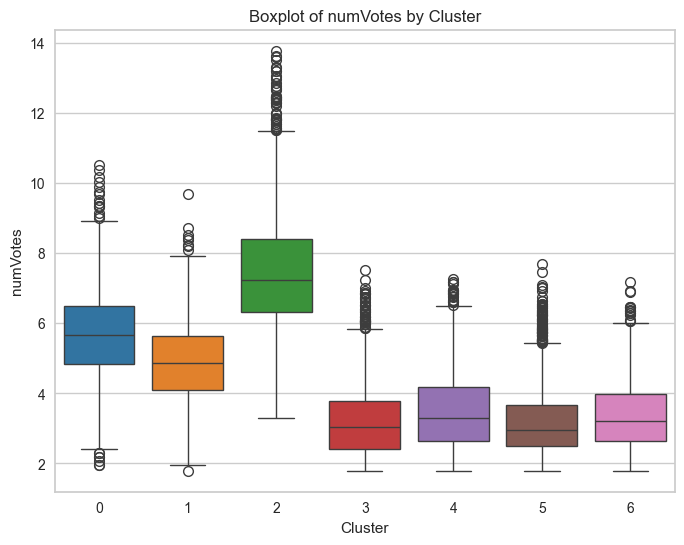

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




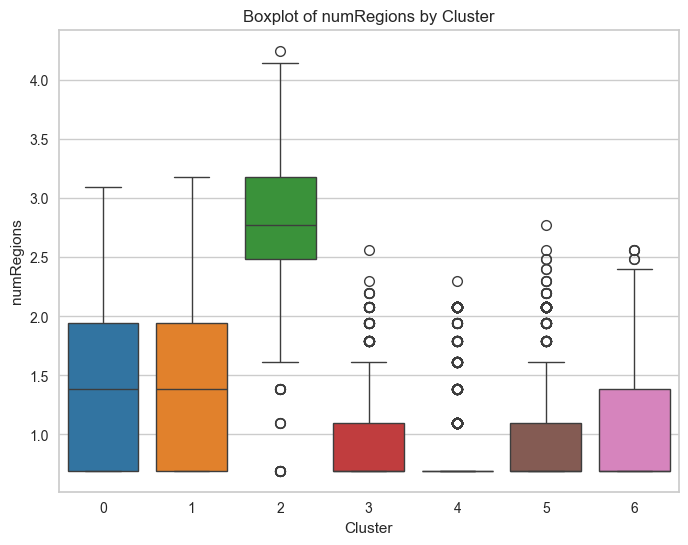

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




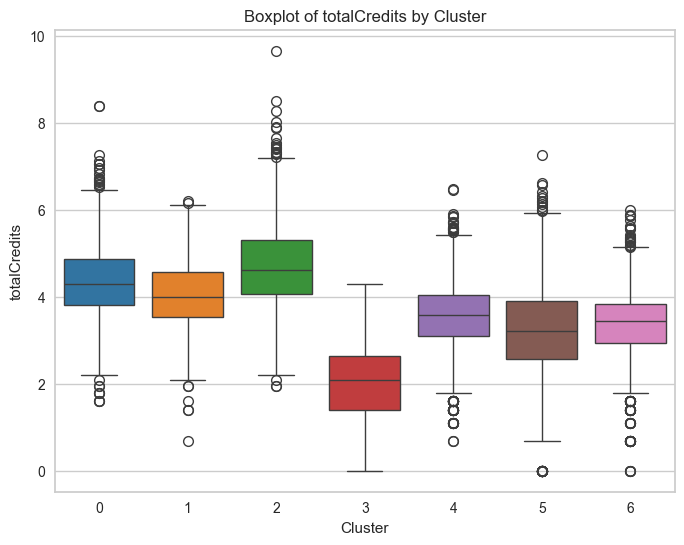

C:\Users\camim\AppData\Local\Temp\ipykernel_6232\1087795411.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




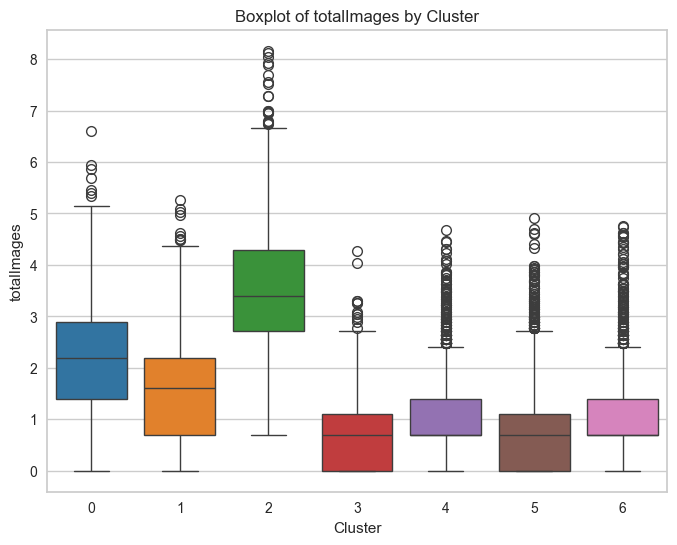

In [120]:
for col in ["numVotes", "numRegions", "totalCredits", "totalImages"]:
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        data=df_clusters, 
        x="Labels", 
        y=col, 
        palette="tab10",
        order=sorted(df_clusters['Labels'].unique())
    )
    plt.title(f"Boxplot of {col} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()

### Statistical frameworks for cluster validity: SSE
Our clustering's SSE is significantly lower than the SSE found in the clustering of 500 randomly generated datasets, which suggests that the clusters found by K-Means in our dataset are meaningful and not a product of chance.

In [69]:
my_sse = bkmeans.inertia_
my_sse

67857.02253696292

In [70]:
N = 500
sse_stats = []

for _ in range(N):
    Xi = np.zeros(shape=X.shape)

    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min_, max_, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min_, max_, (1, nor))

    bkmeans_rand = BisectingKMeans(n_clusters=7, n_init=10, max_iter=100, random_state=94)
    bkmeans_rand.fit(Xi)
    sse_stats.append(bkmeans_rand.inertia_)


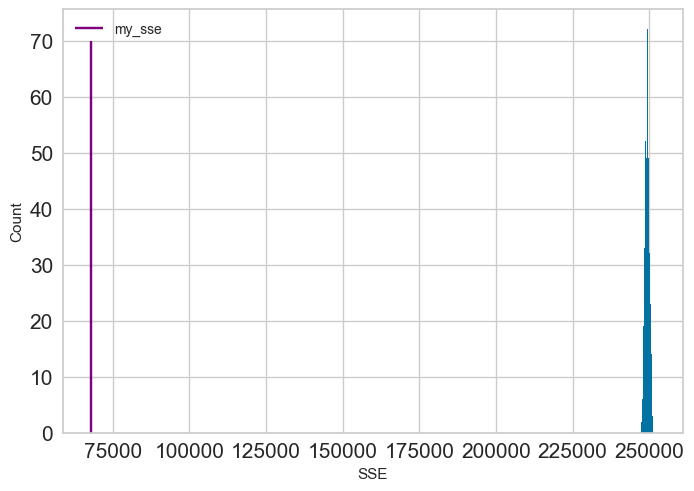

In [71]:
plt.hist(sse_stats, bins='auto')
plt.vlines(x = my_sse, ymin = 0, ymax = 70, colors = 'purple', label = 'my_sse')
plt.xlabel('SSE')
plt.ylabel('Count')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()